In [170]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [171]:
# maybe adapt system paths and pickle version
import sys
import pickle

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypsa
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec
from matplotlib import rc
rc('text', usetex=False) 

import statsmodels.api as sm
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier

#from palettable.cmocean.sequential import Solar_3
#date_string = datetime.datetime.now().strftime("%I_%M_%B_%d")

path = '/media/fkaiser/'

#sys.path.append(path+'Code/power-system-split/power_system_split/')
sys.path.append('../power_system_split/')
#sys.path.append('./')
import utils,visualisation

# Load network and parameters

#### https://jugit.fz-juelich.de/network-science-group/power-system-split/-/blob/master/notebooks/evaluate_component_cluster.ipynb

In [2]:
path_to_pypsa_network   = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'
results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

criterion = 'nodes' # or 'load'
snet_index = 0 # only AC grid of CE
co2ls = np.arange(0.0,0.99,0.05)


In [3]:
# the graph G should be independent of co2l right? so that we can load it out of the loop!?
network = pypsa.Network()
network.import_from_netcdf(path_to_pypsa_network+'elec_s_800_ec_lv1.0_Co2L0.5-3H.nc') # +year+'/elec_s_306_ec_lv1.0_1H.nc')#
G = utils.build_networkx_graph(network, snet_index = snet_index)

/home/jkruse/.conda/envs/system_split/lib/python3.8/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/jkruse/.conda/envs/system_split/lib/python3.8/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.5-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [4]:
bridges = list(nx.bridges(nx.Graph(G)))
non_bridges = list(set(list(G.edges())) - set(bridges))
n_initial_failures = len(non_bridges)
n_time_stamps = network.snapshots.size

number_of_simulations = n_initial_failures*n_time_stamps

# Extract cluster indicator vectors

In [ ]:
component_props = pd.DataFrame(columns= ['co2l','time_stamp', 'number_of_split', 'inertia_proxy', 'load_imbalance', 'available_flexible_generation'])
indicator_vectors = np.empty((0, len(G)),dtype = 'int')

for co2l in co2ls[::-1]:
    print('\n','CO2 level ', co2l)
    level = np.round(co2l,2)
    level_string = f'Co2L{level}'
    print(level_string)
    splitting_cascades = pickle.load(open(results_path+f'system_splits_Co2L{level}.pickle' ,'rb'))
    fname = f'Europe_Co2L{level}_split_evaluation_'+criterion+'_based_snet_%i'%snet_index+'_w_hvdc.pickle'
    solution_dict = pickle.load(open(results_path + fname,'rb'))
   

    indicator_vectors_level, component_props_level = visualisation.indicator_vectors_from_rocof_solution(solution_dict,
                                                                                                        splitting_cascades,
                                                                                                        G, criterion=criterion)

    indicator_vectors = np.concatenate([indicator_vectors, indicator_vectors_level])
    component_props_level.loc[:, 'co2l'] = co2l
    component_props = component_props.append(component_props_level, ignore_index=True)
    
indicator_vectors_int = indicator_vectors.astype('int')


  0%|          | 0/2920 [00:00<?, ?it/s]


 CO2 level  0.9500000000000001
Co2L0.95


  0%|          | 0/2920 [00:00<?, ?it/s]


 CO2 level  0.9
Co2L0.9


  0%|          | 0/2920 [00:00<?, ?it/s]

...

100%|██████████| 2920/2920 [06:29<00:00,  7.50it/s]



 CO2 level  0.25
Co2L0.25


100%|██████████| 2920/2920 [06:56<00:00,  7.00it/s]



 CO2 level  0.2
Co2L0.2


100%|█████████▉| 2906/2920 [07:27<00:04,  3.09it/s]

In [535]:
print(component_props)

        co2l     time_stamp  number_of_split  inertia_proxy  load_imbalance  \
0       0.95  01_01_2013_00              8.0  141109.542791     3084.006284   
1       0.95  01_01_2013_00              8.0   20914.998000    -2740.636591   
2       0.95  01_01_2013_00             15.0  162024.430791    -3718.444712   
3       0.95  01_01_2013_00             15.0       0.110000     3718.462839   
4       0.95  01_01_2013_00             21.0  161871.540791     2221.349891   
...      ...            ...              ...            ...             ...   
674718  0.00  31_12_2013_21             61.0       0.000000     6998.819003   
674719  0.00  31_12_2013_21             62.0   54267.670579     4406.796371   
674720  0.00  31_12_2013_21             62.0    9871.258000    -1947.554254   
674721  0.00  31_12_2013_21             71.0   64079.315179   -12492.771706   
674722  0.00  31_12_2013_21             71.0       0.110000     6436.695018   

       available_flexible_generation  cluster_label

In [352]:
#np.save(results_path + 'indicator_vectors_all_co2level_{}_based_w_hvdc.npy'.format(criterion),indicator_vectors_int)
#component_props.to_hdf(results_path + 'split_component_properties_all_co2level_{}_based_w_hvdc.h5'.format(criterion), key='df')

# Not used:  sparse.save_npz(results_path + 'indicator_vectors_all_co2level_{}_based_new.npz'.format(criterion), sparse_vectors)


# Cluster indicator vectors

## Load data

In [5]:
indicator_vectors = np.load(results_path + 'indicator_vectors_all_co2level_{}_based_w_hvdc.npy'.format(criterion))
indicator_vectors

array([[1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 0, 0, 0]])

In [6]:
component_props = pd.read_hdf(results_path + 'split_component_properties_all_co2level_{}_based_w_hvdc.h5'.format(criterion))
component_props

,co2l,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation
0,0.95,01_01_2013_00,8.0,141109.542791,3084.006284,NaN
1,0.95,01_01_2013_00,8.0,20914.998000,-2740.636591,NaN
2,0.95,01_01_2013_00,15.0,162024.430791,-3718.444712,NaN
3,0.95,01_01_2013_00,15.0,0.110000,3718.462839,NaN
4,0.95,01_01_2013_00,21.0,161871.540791,2221.349891,NaN
...,...,...,...,...,...,...
674718,0.00,31_12_2013_21,61.0,0.000000,6998.819003,NaN
674719,0.00,31_12_2013_21,62.0,54267.670579,4406.796371,NaN
674720,0.00,31_12_2013_21,62.0,9871.258000,-1947.554254,NaN
674721,0.00,31_12_2013_21,71.0,64079.315179,-12492.771706,NaN


In [134]:
component_props.co2l = component_props.co2l.round(2)

## Agglomerate subset of indicator vectors to identify major clusters

In [29]:
# Select subset of components for random time stemps and co2 levels
indices_all_components = np.arange(indicator_vectors.shape[0])
np.random.shuffle(indices_all_components)
subset_size = 0.01
subset_indices = indices_all_components[:int(subset_size*indicator_vectors.shape[0])]
remaining_indices = indices_all_components[int(subset_size*indicator_vectors.shape[0]):]
print(subset_indices.size, 'components will be used.')
print(remaining_indices.size, 'components will be assigned via NN classification.')

6747 components will be used.
667976 components will be assigned via NN classification.


In [30]:
# Identify cluster in subset
min_cluster_distance = 9./ len(G) 
n_cluster, subset_cluster_labels = visualisation.cluster_indicator_vectors_agglomerative(indicator_vectors[subset_indices], 
                                                                                  min_cluster_distance = min_cluster_distance,
                                                                                  cluster_distance_type = 'average')

component_props.loc[:, 'cluster_label'] = np.nan
component_props.loc[subset_indices, 'cluster_label'] = subset_cluster_labels
n_cluster

119

## Assign remaining vectors to clusters via Nearest-Neighbor classifier

In [22]:
rnc = RadiusNeighborsClassifier(radius= min_cluster_distance, metric='hamming', outlier_label=-1, n_jobs=20)
rnc.fit(indicator_vectors[subset_indices], subset_cluster_labels)

RadiusNeighborsClassifier(metric='hamming', n_jobs=20, outlier_label=-1,
                          radius=0.014802631578947368)

In [32]:
remaining_cluster_labels = rnc.predict(indicator_vectors[remaining_indices])
component_props.loc[remaining_indices,'cluster_label'] = remaining_cluster_labels

/home/jkruse/.conda/envs/system_split/lib/python3.8/site-packages/sklearn/neighbors/_classification.py:601: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn('Outlier label {} is not in training '


In [33]:
print(component_props.shape)
print(indicator_vectors.shape)
np.unique(component_props["cluster_label"])

(674723, 7)
(674723, 608)


array([ -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,
        10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,
        21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,
        32.,  33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,
        43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,
        54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,
        65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,
        76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,
        87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,
        98.,  99., 100., 101., 102., 103., 104., 105., 106., 107., 108.,
       109., 110., 111., 112., 113., 114., 115., 116., 117., 118.])

# Evaluate cluster and component properties

In [34]:
# Add component properties
component_props.loc[:,'rocof'] = component_props.load_imbalance / component_props.inertia_proxy*50/2/6
component_props.loc[:, 'number_of_nodes'] = indicator_vectors.sum(1)
component_props.loc[:,'inertia_proxy'] = component_props.inertia_proxy


# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby(['cluster_label','co2l']).size().to_frame('counts')
cluster_props.loc[:,'likelihood'] = cluster_props.counts.div(number_of_simulations)
cluster_props.loc[:,'mean_number_of_nodes'] = component_props.groupby(['cluster_label','co2l'])['number_of_nodes'].mean()

# Count infinity rocofs and then set them no nan in component properties
cluster_props.loc[:,'number_pos_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isposinf(x.rocof).sum())
cluster_props.loc[:,'number_neg_inf_rocofs'] = component_props.groupby(['cluster_label','co2l']).apply(lambda x: np.isneginf(x.rocof).sum())
component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].replace([np.inf, -np.inf], np.nan).dropna()

cluster_props.loc[:,'median_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].median()
cluster_props.loc[:,'upper_quantile_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].quantile(0.75)
cluster_props.loc[:,'lower_quantile_inertia_proxy'] = component_props.groupby(['cluster_label','co2l'])['inertia_proxy'].quantile(0.25)

# Calculate rocof statistics for each cluster given a certain co2 level
cluster_props.loc[:,'median_rocof'] = component_props.groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'median_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].median()
cluster_props.loc[:,'mean_pos_rocof'] = (component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof']).apply(lambda g: g.mean(skipna=False))
cluster_props.loc[:,'min_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05) #.min()
cluster_props.loc[:,'max_pos_rocof'] = component_props[component_props.rocof>0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95) #.max()
cluster_props.loc[:,'median_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].median().abs()
cluster_props.loc[:,'upper_quantile_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.75).abs()
cluster_props.loc[:,'lower_quantile_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.25).abs()

cluster_props.loc[:,'mean_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].apply(lambda g: g.mean(skipna=False)).abs()
cluster_props.loc[:,'max_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.05).abs() #min()
cluster_props.loc[:,'min_neg_rocof'] = component_props[component_props.rocof<=0].groupby(['cluster_label','co2l'])['rocof'].quantile(0.95).abs() #max()

# convert rocof to absolute rocof and save sign
#component_props.loc[:,'rocof_positive'] = component_props.loc[:,'rocof']>0
#component_props.loc[:,'rocof'] = component_props.loc[:,'rocof'].abs()

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.head()

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
-1.0          0.00     820    0.000294            295.817073   
              0.05     515    0.000184            319.295146   
              0.10     329    0.000118            294.504559   
              0.15     245    0.000088            319.318367   
              0.20     245    0.000088            335.926531   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
-1.0          0.00                     29                      3   
              0.05                     13                      0   
              0.10                     14                      1   
              0.15                      0                      0   
              0.20                      3                      0   

                    median_inertia_proxy  upper_quantile_inertia_proxy  \
cluster_label co2l                                                       
-1.0          0.00          28798.447220                  54665.581596   
              0.05          36260.652378                  74149.086279   
              0.10          35133.698119                  82858.117641   
              0.15          55762.337375                 100741.761880   
              0.20          59052.573922                 116752.058559   

                    lower_quantile_inertia_proxy  median_rocof  \
cluster_label co2l                                               
-1.0          0.00                   1675.342445      0.351268   
              0.05                   3428.374486     -0.403156   
              0.10                   2742.253989     -0.439172   
              0.15                   8725.262730     -0.393514   
              0.20                  25457.832300     -0.333623   

                    median_pos_rocof  mean_pos_rocof  min_pos_rocof  \
cluster_label co2l                                                    
-1.0          0.00          5.977422      277.104401       0.240821   
              0.05          7.665118      351.394356       0.456369   
              0.10          8.916061      299.146867       0.526884   
              0.15          5.154496      196.850695       0.670994   
              0.20          1.980363       99.233578       0.324087   

                    max_pos_rocof  median_neg_rocof  upper_quantile_neg_rocof  \
cluster_label co2l                                                              
-1.0          0.00    1788.846222          1.421573                  0.982911   
              0.05    1853.439781          0.975055                  0.600512   
              0.10    1764.279160          0.916053                  0.530357   
              0.15    1422.986308          0.717105                  0.406492   
              0.20     394.129221          0.715135                  0.368262   

                    lower_quantile_neg_rocof  mean_neg_rocof  max_neg_rocof  \
cluster_label co2l                                                            
-1.0          0.00                  2.772048       31.075825     111.292975   
              0.05                  1.829143        8.398269      13.538848   
              0.10                  1.608024       13.412963      65.388833   
              0.15                  1.548118       10.903865      19.549124   
              0.20                  1.357978        2.033658       5.722324   

                    min_neg_rocof  
cluster_label co2l                 
-1.0          0.00       0.470981  
              0.05       0.313494  
              0.10       0.244277  
              0.15       0.191244  
              0.20       0.141478

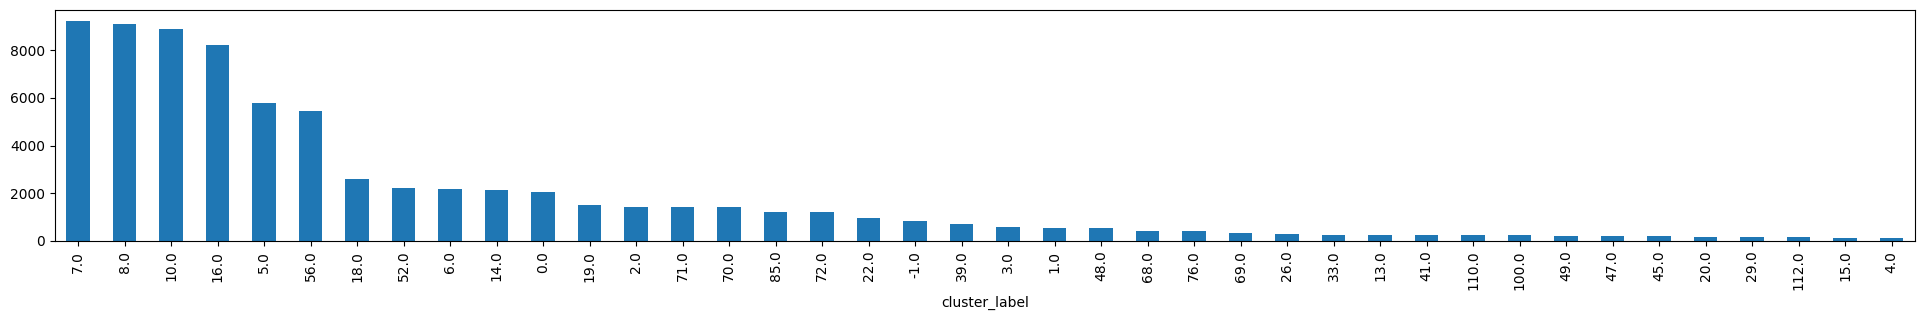

In [35]:
cluster_props.groupby('cluster_label').apply(lambda x: x.counts.max()).sort_values().iloc[::-1].iloc[:40].plot.bar(figsize=(24,3),
                                                                                                                   subplots=False)
plt.show()
# check how fast cluster probabilities decrease and for how much cases the selected ones account for

In [49]:
 # Only select cluster if there is at least one co2l with P(cluster | co2l) significantly larger than p (alpha=0.05)
# (i.e. we omit very unlikely clusters)
p = 0.001
min_count, max_counts = sm.stats.binom_test_reject_interval(p,number_of_simulations, alternative='larger', alpha=0.05)
print('Rejected if less than', int(max_counts), 'hits in all', number_of_simulations, 'simulations')

#selected_cluster = cluster_props.index[cluster_props.counts>max_counts]
#n_selected_cluster = selected_cluster.get_level_values('cluster_label').unique().size

selected_cluster_mask = cluster_props.groupby('cluster_label').apply(lambda x: (x.counts>max_counts).any())
selected_cluster = selected_cluster_mask[selected_cluster_mask].index
n_selected_cluster = selected_cluster.size

print('Labels of selected cluster:', selected_cluster)
print('Number of selected cluster:', n_selected_cluster)

Rejected if less than 2880 hits in all 2791520 simulations
Labels of selected cluster: Float64Index([5.0, 7.0, 8.0, 10.0, 16.0, 56.0], dtype='float64', name='cluster_label')
Number of selected cluster: 6


# Visualize results

## Plot cluster

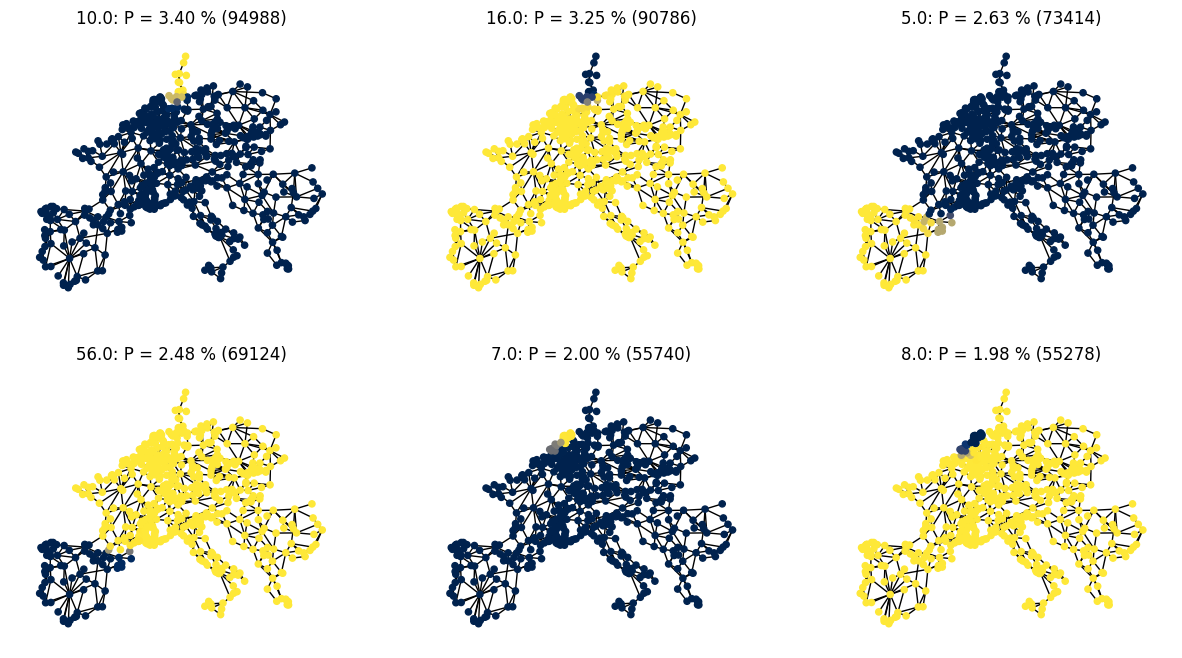

In [50]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 3 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,4*n_rows))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label
selected_cluster_props = cluster_props.loc[:,['likelihood', 'counts']].groupby('cluster_label').sum()
selected_cluster_props = selected_cluster_props[selected_cluster_props.index.isin(selected_cluster_labels)]

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     selected_cluster_props,
                                     G)
plt.show()

## Plot cluster properties

In [161]:
cluster_props.cluster_label

AttributeError: 'DataFrame' object has no attribute 'cluster_label'

In [ ]:
n_col = 5
co2l_colors = plt.get_cmap('cividis')(range(co2ls.size))
fig, ax = plt.subplots(n_selected_cluster, n_cols, figsize=(11,9))

for ax_row, label in enumerate(selected_cluster):
    
    
    # split map
    visualisation.plot_component_cluster(indicator_vectors[component_props.cluster_label==label],
                                         [ax[ax_row, 0]],
                                         component_props[component_props.cluster_label==label].cluster_label.values,
                                         '',
                                         G,
                                         5)
    
    data = component_props[(component_props.cluster_label==label) & (component_props.co2l.isin([0.05, 0.95]))  ]
    nbins = 'scott' #data.groupby('co2l').size() // 50
       
    # inertia
    gfg = sns.histplot(data=data,
                 x='inertia_proxy', hue='co2l', ax=ax[ax_row, 1],
                 bins=nbins ,
                 legend=(ax_row==1),element="step",  fill=True, log_scale=(False, True),
                 binrange=[0, data.groupby('co2l').inertia_proxy.quantile(0.99).max()])
    ax[ax_row, 1].set_xlabel('')
    if ax_row==1:
        plt.setp(gfg.get_legend().get_texts(), fontsize=7)
        #gfg.legend_.set_title(None)
    # delta p
    sns.histplot(data=data,
                 x='load_imbalance', hue='co2l', ax=ax[ax_row, 2],
                 bins= nbins,
                 legend=False,element="step",  fill=True, log_scale=(False, True),
                 binrange=[data.groupby('co2l').rocof.quantile(0.01).min(), data.groupby('co2l').load_imbalance.quantile(0.99).max()])
    ax[ax_row, 2].set_xlabel('')
    ax[ax_row, 2].set_ylabel('')
    
    # rocof
    sns.histplot(data=data,
                 x='rocof', hue='co2l', ax=ax[ax_row, 3],
                 bins=nbins ,
                 legend=False,element="step",  fill=True,log_scale=(False, True),
                 binrange=[data.groupby('co2l').rocof.quantile(0.01).min(), data.groupby('co2l').rocof.quantile(0.99).max()])
    ax[ax_row, 3].set_xlabel('')
    ax[ax_row, 3].set_ylabel('')
    
    # likelihood
    
    sns.lineplot(data = cluster_props.xs(label, level='cluster_label') ,
                x = 'co2l',
                y = 'likelihood', ax=ax[ax_row, 4])
    ax[ax_row, 4].set_xlabel('')


ax[-1,1].set_xlabel('Inertia')
ax[-1,2].set_xlabel('Load imbalance')
ax[-1,3].set_xlabel('Rocof')
ax[-1,4].set_xlabel('Co2 level')

plt.tight_layout()
plt.show()

In [51]:
selected_components = component_props[component_props.cluster_label.isin(selected_cluster)]
cluster_props.loc[selected_cluster]

counts  likelihood  mean_number_of_nodes  \
cluster_label co2l                                             
5.0           0.00    5766    0.002066             71.623656   
              0.05    4218    0.001511             70.407776   
              0.10    4168    0.001493             69.912668   
              0.15    3929    0.001407             70.012217   
              0.20    3414    0.001223             70.137668   
...                    ...         ...                   ...   
56.0          0.75    2770    0.000992            534.995668   
              0.80    2760    0.000989            535.001087   
              0.85    2757    0.000988            534.998912   
              0.90    2758    0.000988            534.996374   
              0.95    2762    0.000989            534.994569   

                    number_pos_inf_rocofs  number_neg_inf_rocofs  \
cluster_label co2l                                                 
5.0           0.00                      0                      0   
              0.05                      0                      0   
              0.10                     12                      0   
              0.15                     10                      0   
              0.20                      9                      0   
...                                   ...                    ...   
56.0          0.75                      0                      0   
              0.80                      0                      0   
              0.85                      0                      0   
              0.90                      0                      0   
              0.95                      0                      0   

                    median_inertia_proxy  upper_quantile_inertia_proxy  \
cluster_label co2l                                                       
5.0           0.00          10104.178000                  13073.958000   
              0.05          10298.348000                  13743.631000   
              0.10          10338.228000                  13539.328000   
              0.15          10234.593000                  13720.555000   
              0.20          10129.353000                  14321.950000   
...                                  ...                           ...   
56.0          0.75         210751.638301                 228888.198425   
              0.80         210388.867929                 228935.221912   
              0.85         210139.178961                 228822.292372   
              0.90         210077.296953                 229185.011436   
              0.95         210658.783532                 228824.562371   

                    lower_quantile_inertia_proxy  median_rocof  \
cluster_label co2l                                               
5.0           0.00                   9558.128000     -0.978505   
              0.05                   8478.853000     -0.478770   
              0.10                   8478.853000      0.346485   
              0.15                   8478.853000      0.431336   
              0.20                   8478.853000      0.402188   
...                                          ...           ...   
56.0          0.75                 184313.564020     -0.041656   
              0.80                 184184.389020     -0.041573   
              0.85                 184198.279818     -0.041671   
              0.90                 184198.279818     -0.041575   
              0.95                 184247.595355     -0.041756   

                    median_pos_rocof  mean_pos_rocof  min_pos_rocof  \
cluster_label co2l                                                    
5.0           0.00          1.136078        1.495927       0.366114   
              0.05          1.473257       70.472447       0.416951   
              0.10          1.432907        2.426546       0.403556   
              0.15          1.388023        2.743430       0.378557   
              0.20          1.158336       46.772404  

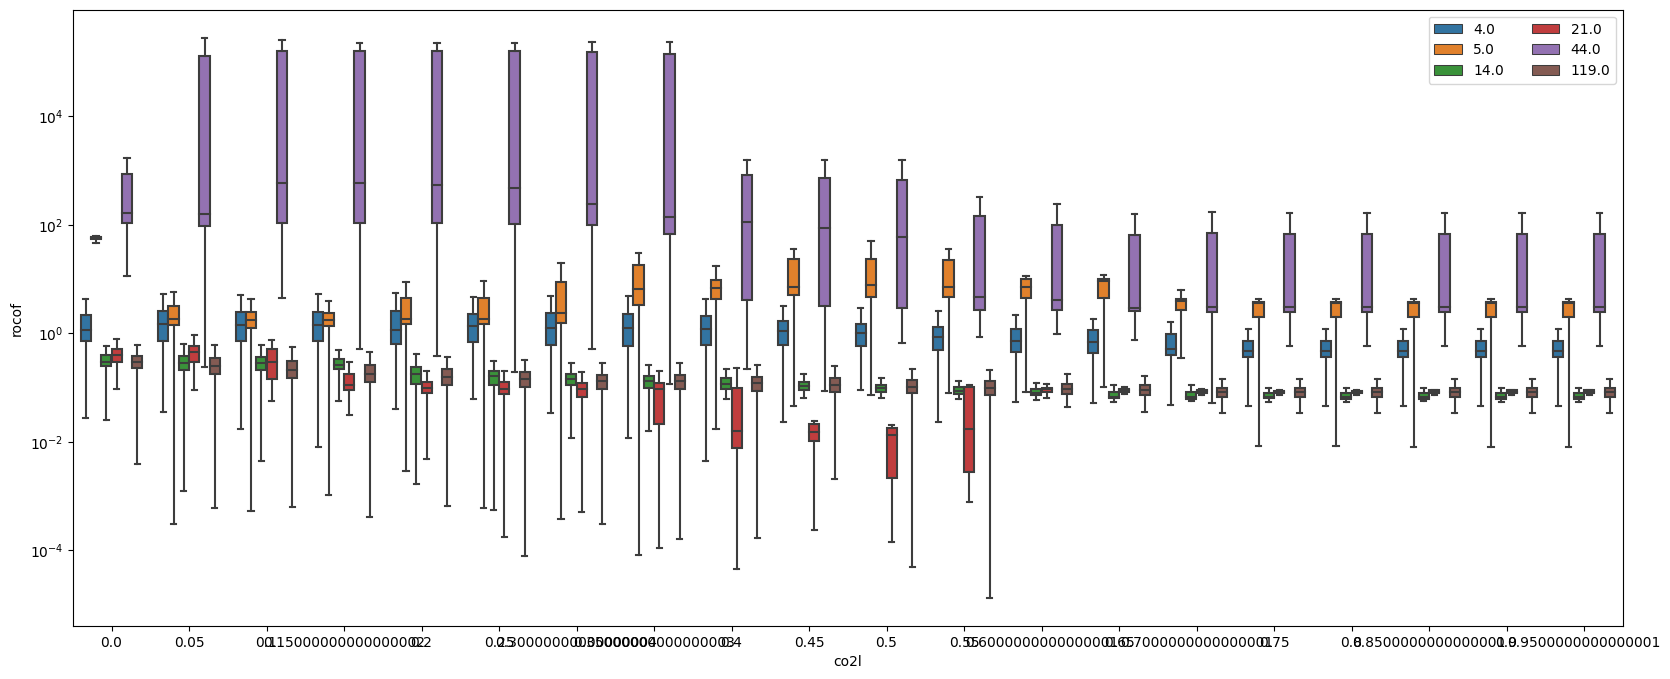

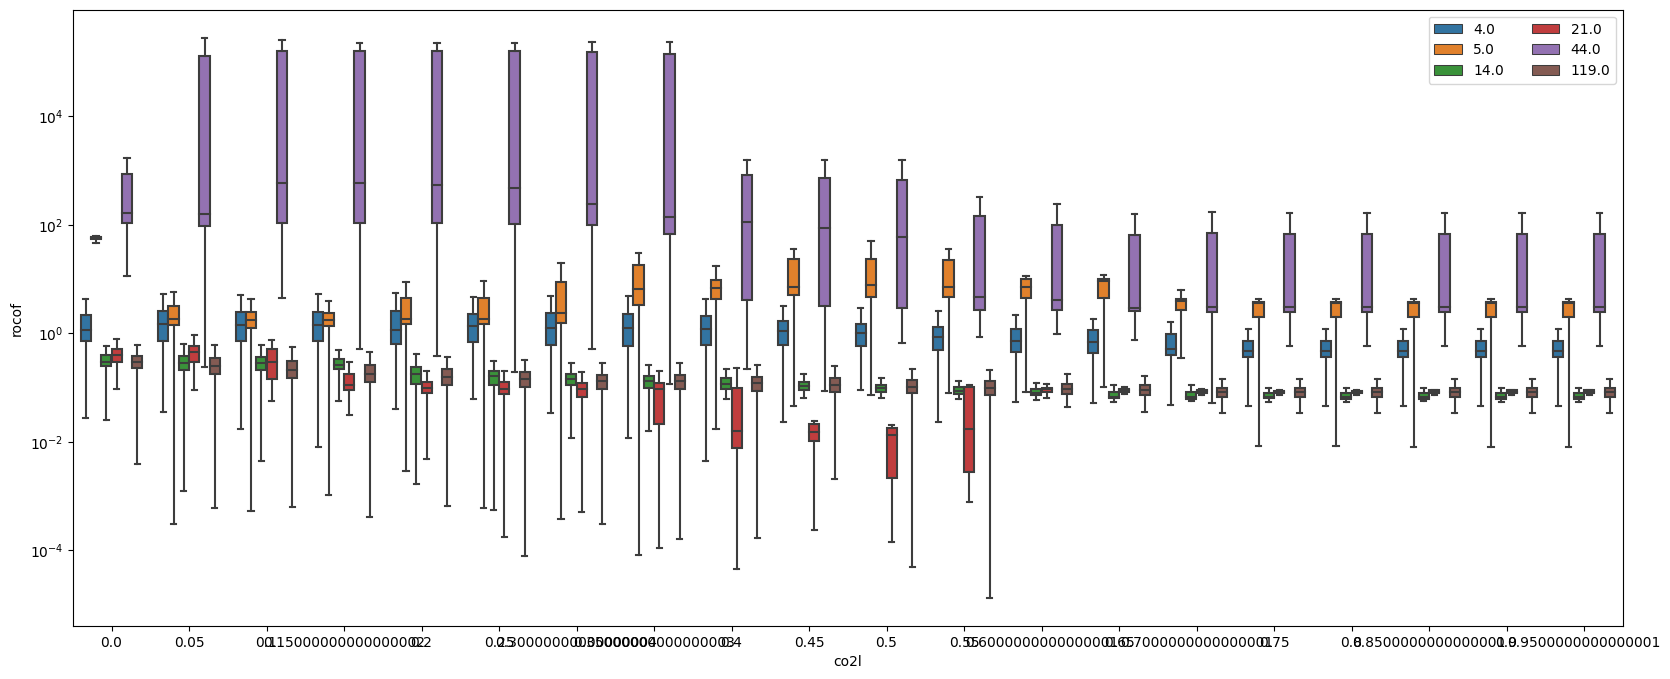

In [64]:
plt.figure(figsize=(20,8))
sns.boxplot(data=selected_components[selected_components.rocof_positive], x='co2l', y='rocof', hue='cluster_label', showfliers=False)
plt.legend(ncol=2)
#plt.xlim([-0.5,6])
plt.yscale('log') 
plt.show()

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


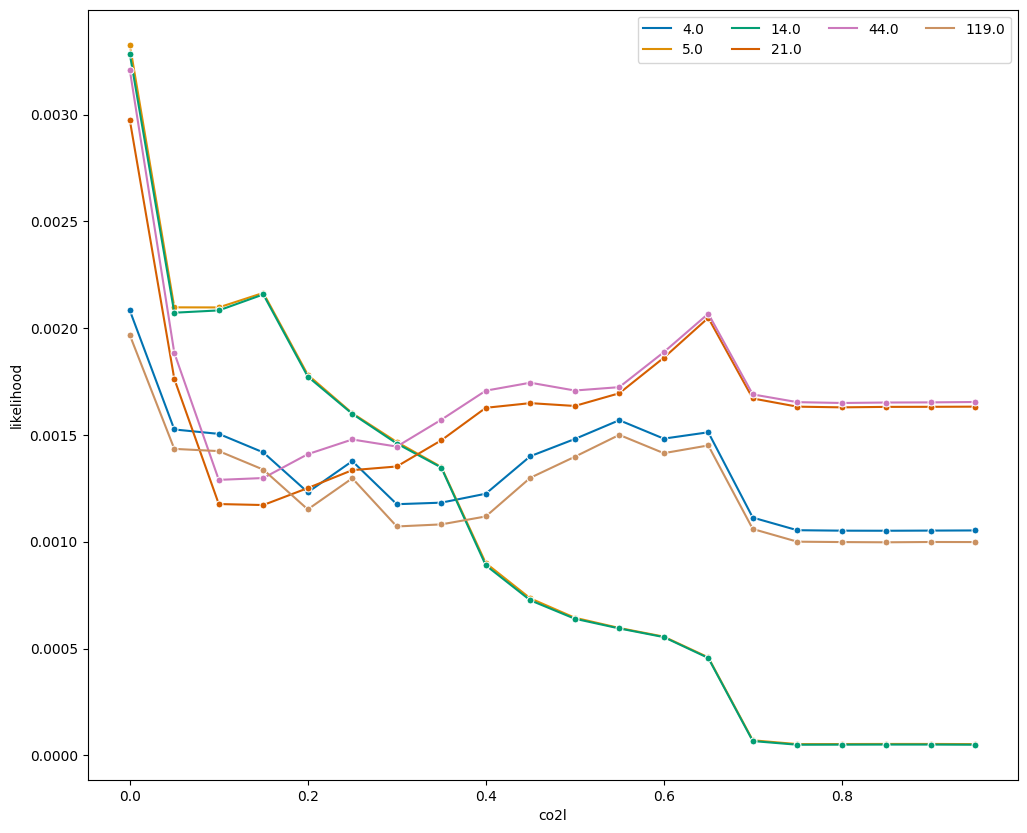

In [65]:
f,ax = plt.subplots(figsize=(12,10))

colors = sns.color_palette('colorblind')
print(colors)

sns.lineplot(data = cluster_props.loc[selected_cluster].reset_index() ,
             x = 'co2l',
             y = 'likelihood',
             hue = 'cluster_label',
             marker = '.', 
             ms = 10, 
             palette = 'colorblind')
#plt.yscale('log')
plt.legend(ncol=4)
plt.show()

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


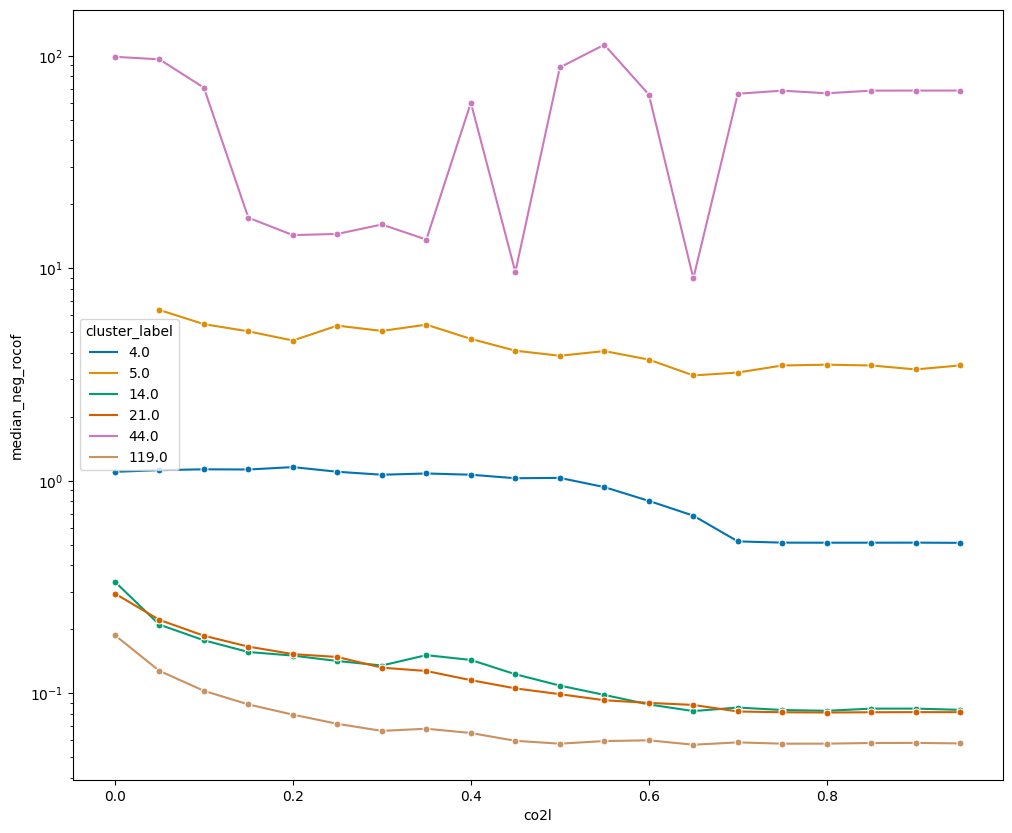

In [70]:
f,ax = plt.subplots(figsize=(12,10))

colors = sns.color_palette('colorblind')
print(colors)

sns.lineplot(data = cluster_props.loc[selected_cluster].reset_index() , 
             x = 'co2l', 
             y = 'median_neg_rocof', 
             hue = 'cluster_label', 
             marker = '.', 
             ms = 10, 
             palette = 'colorblind')#colors[:6])
#plt.yscale('log')


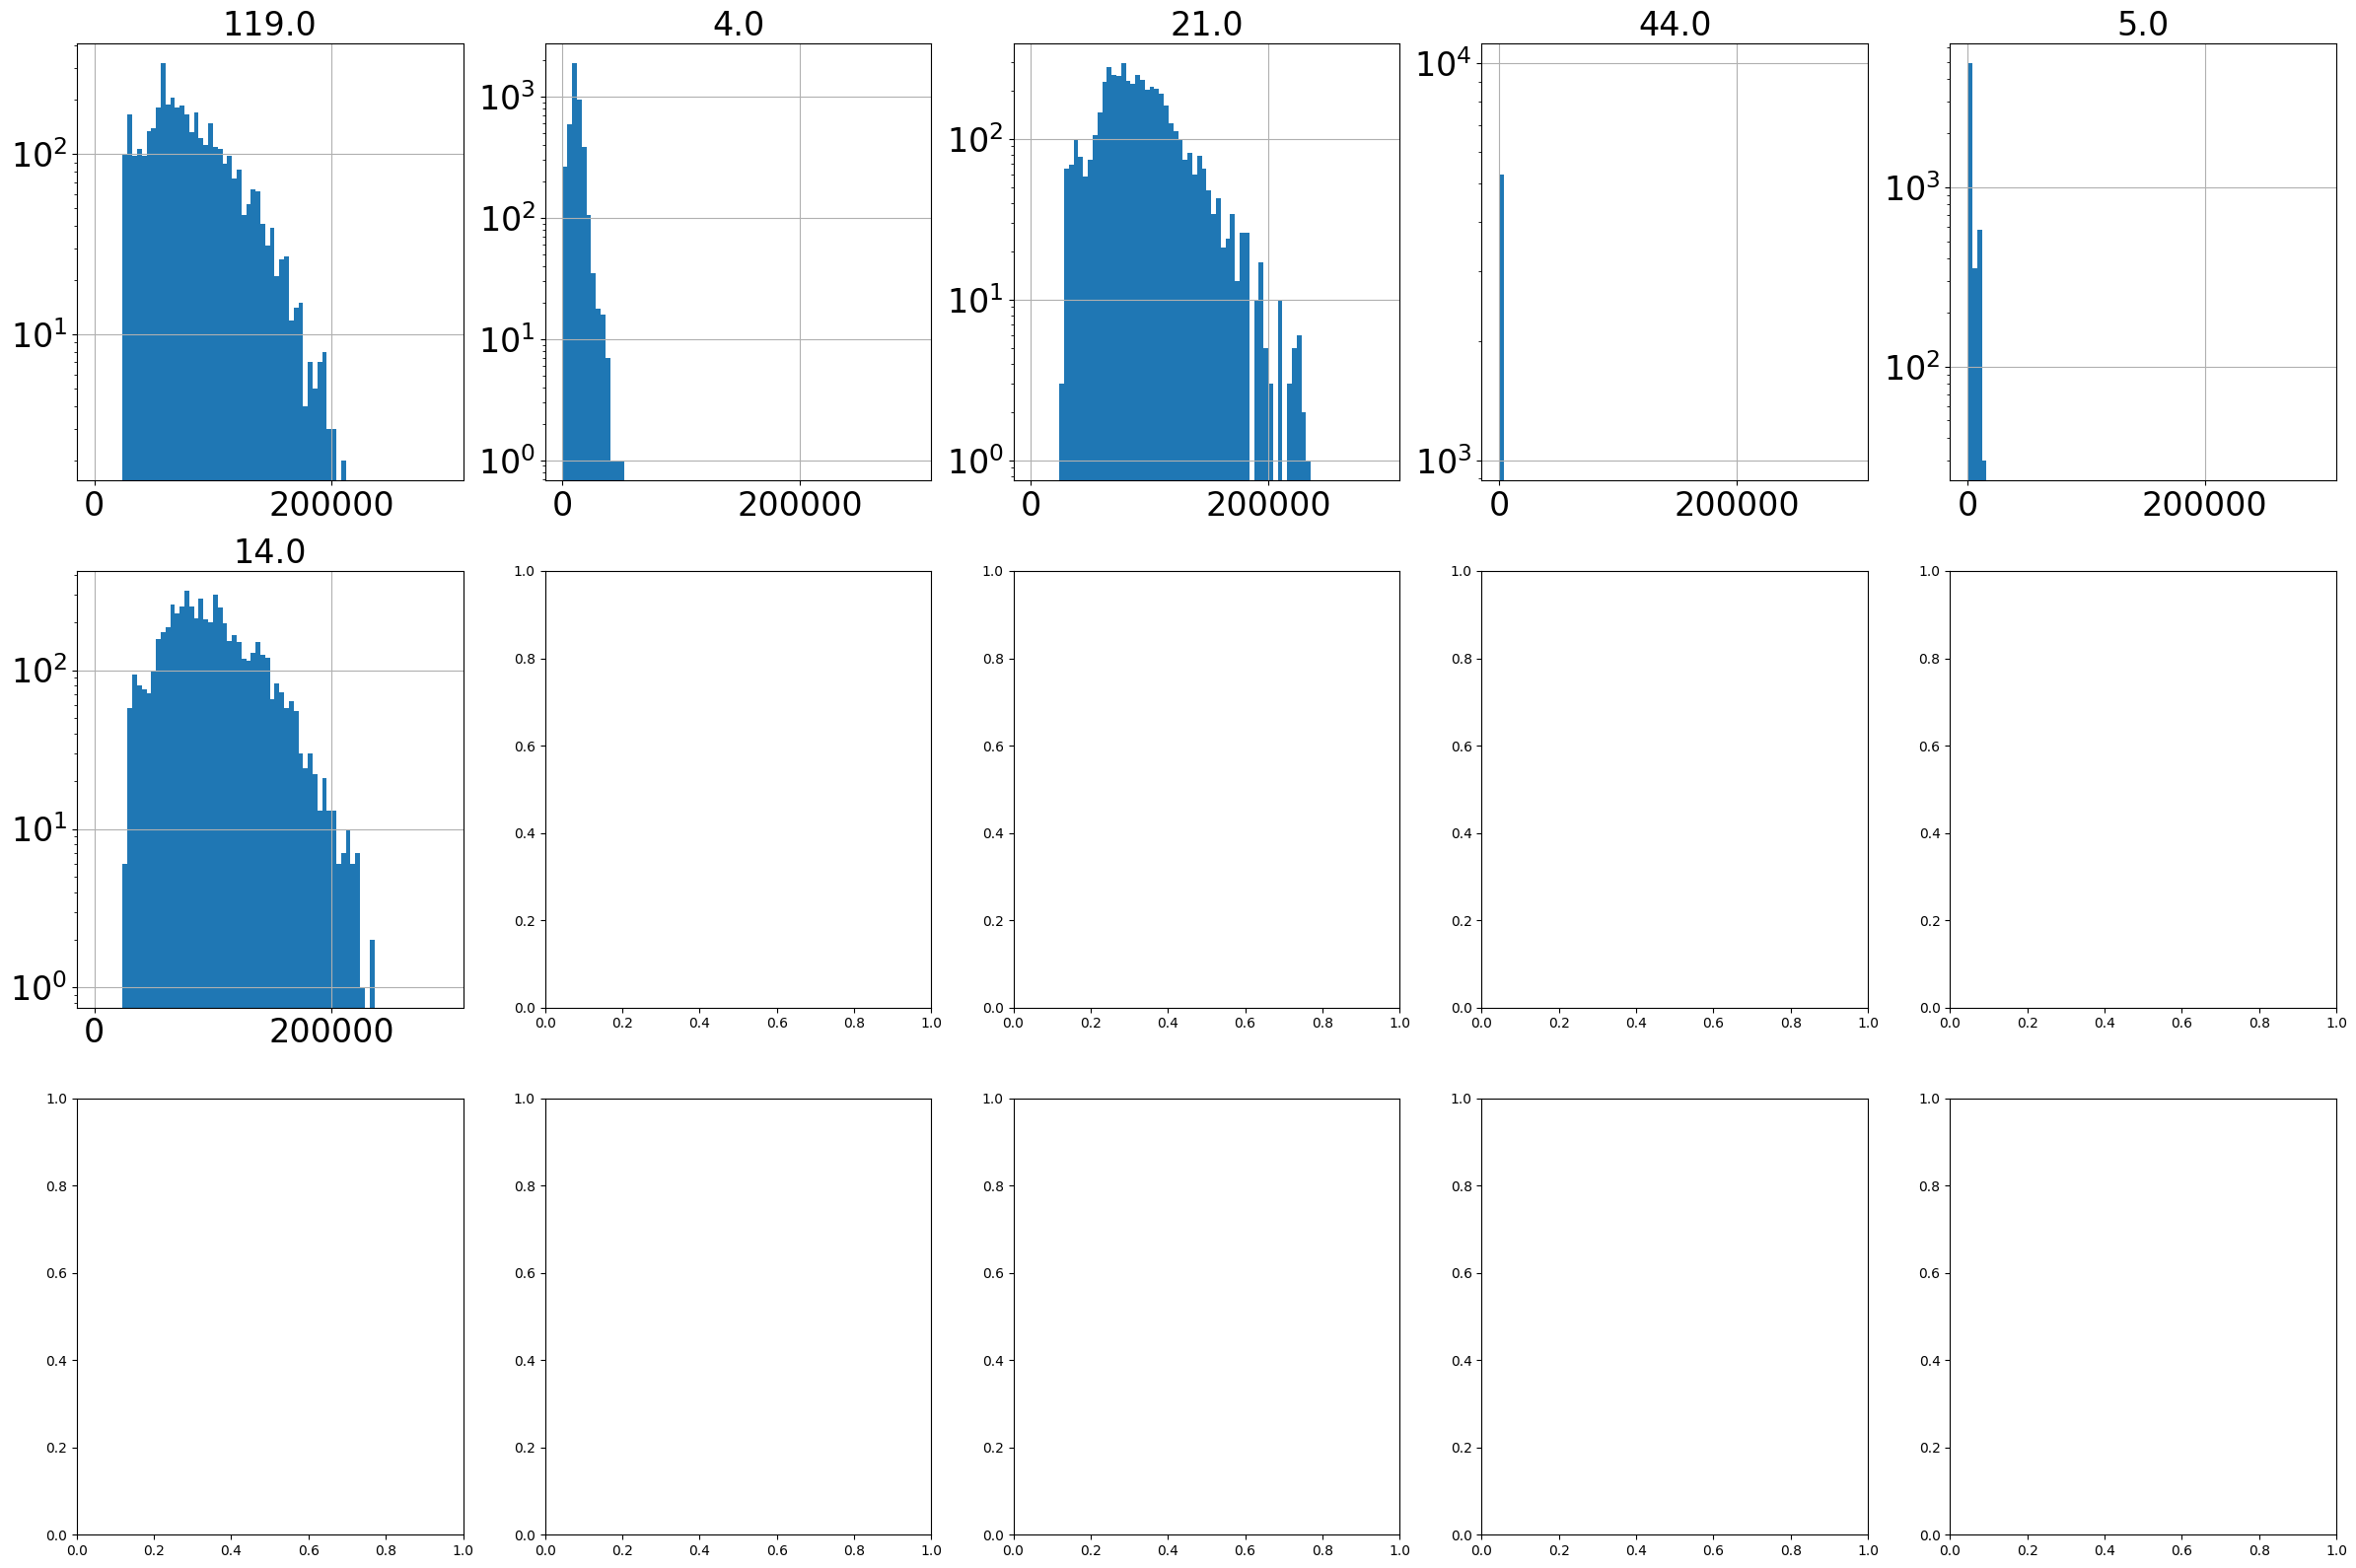

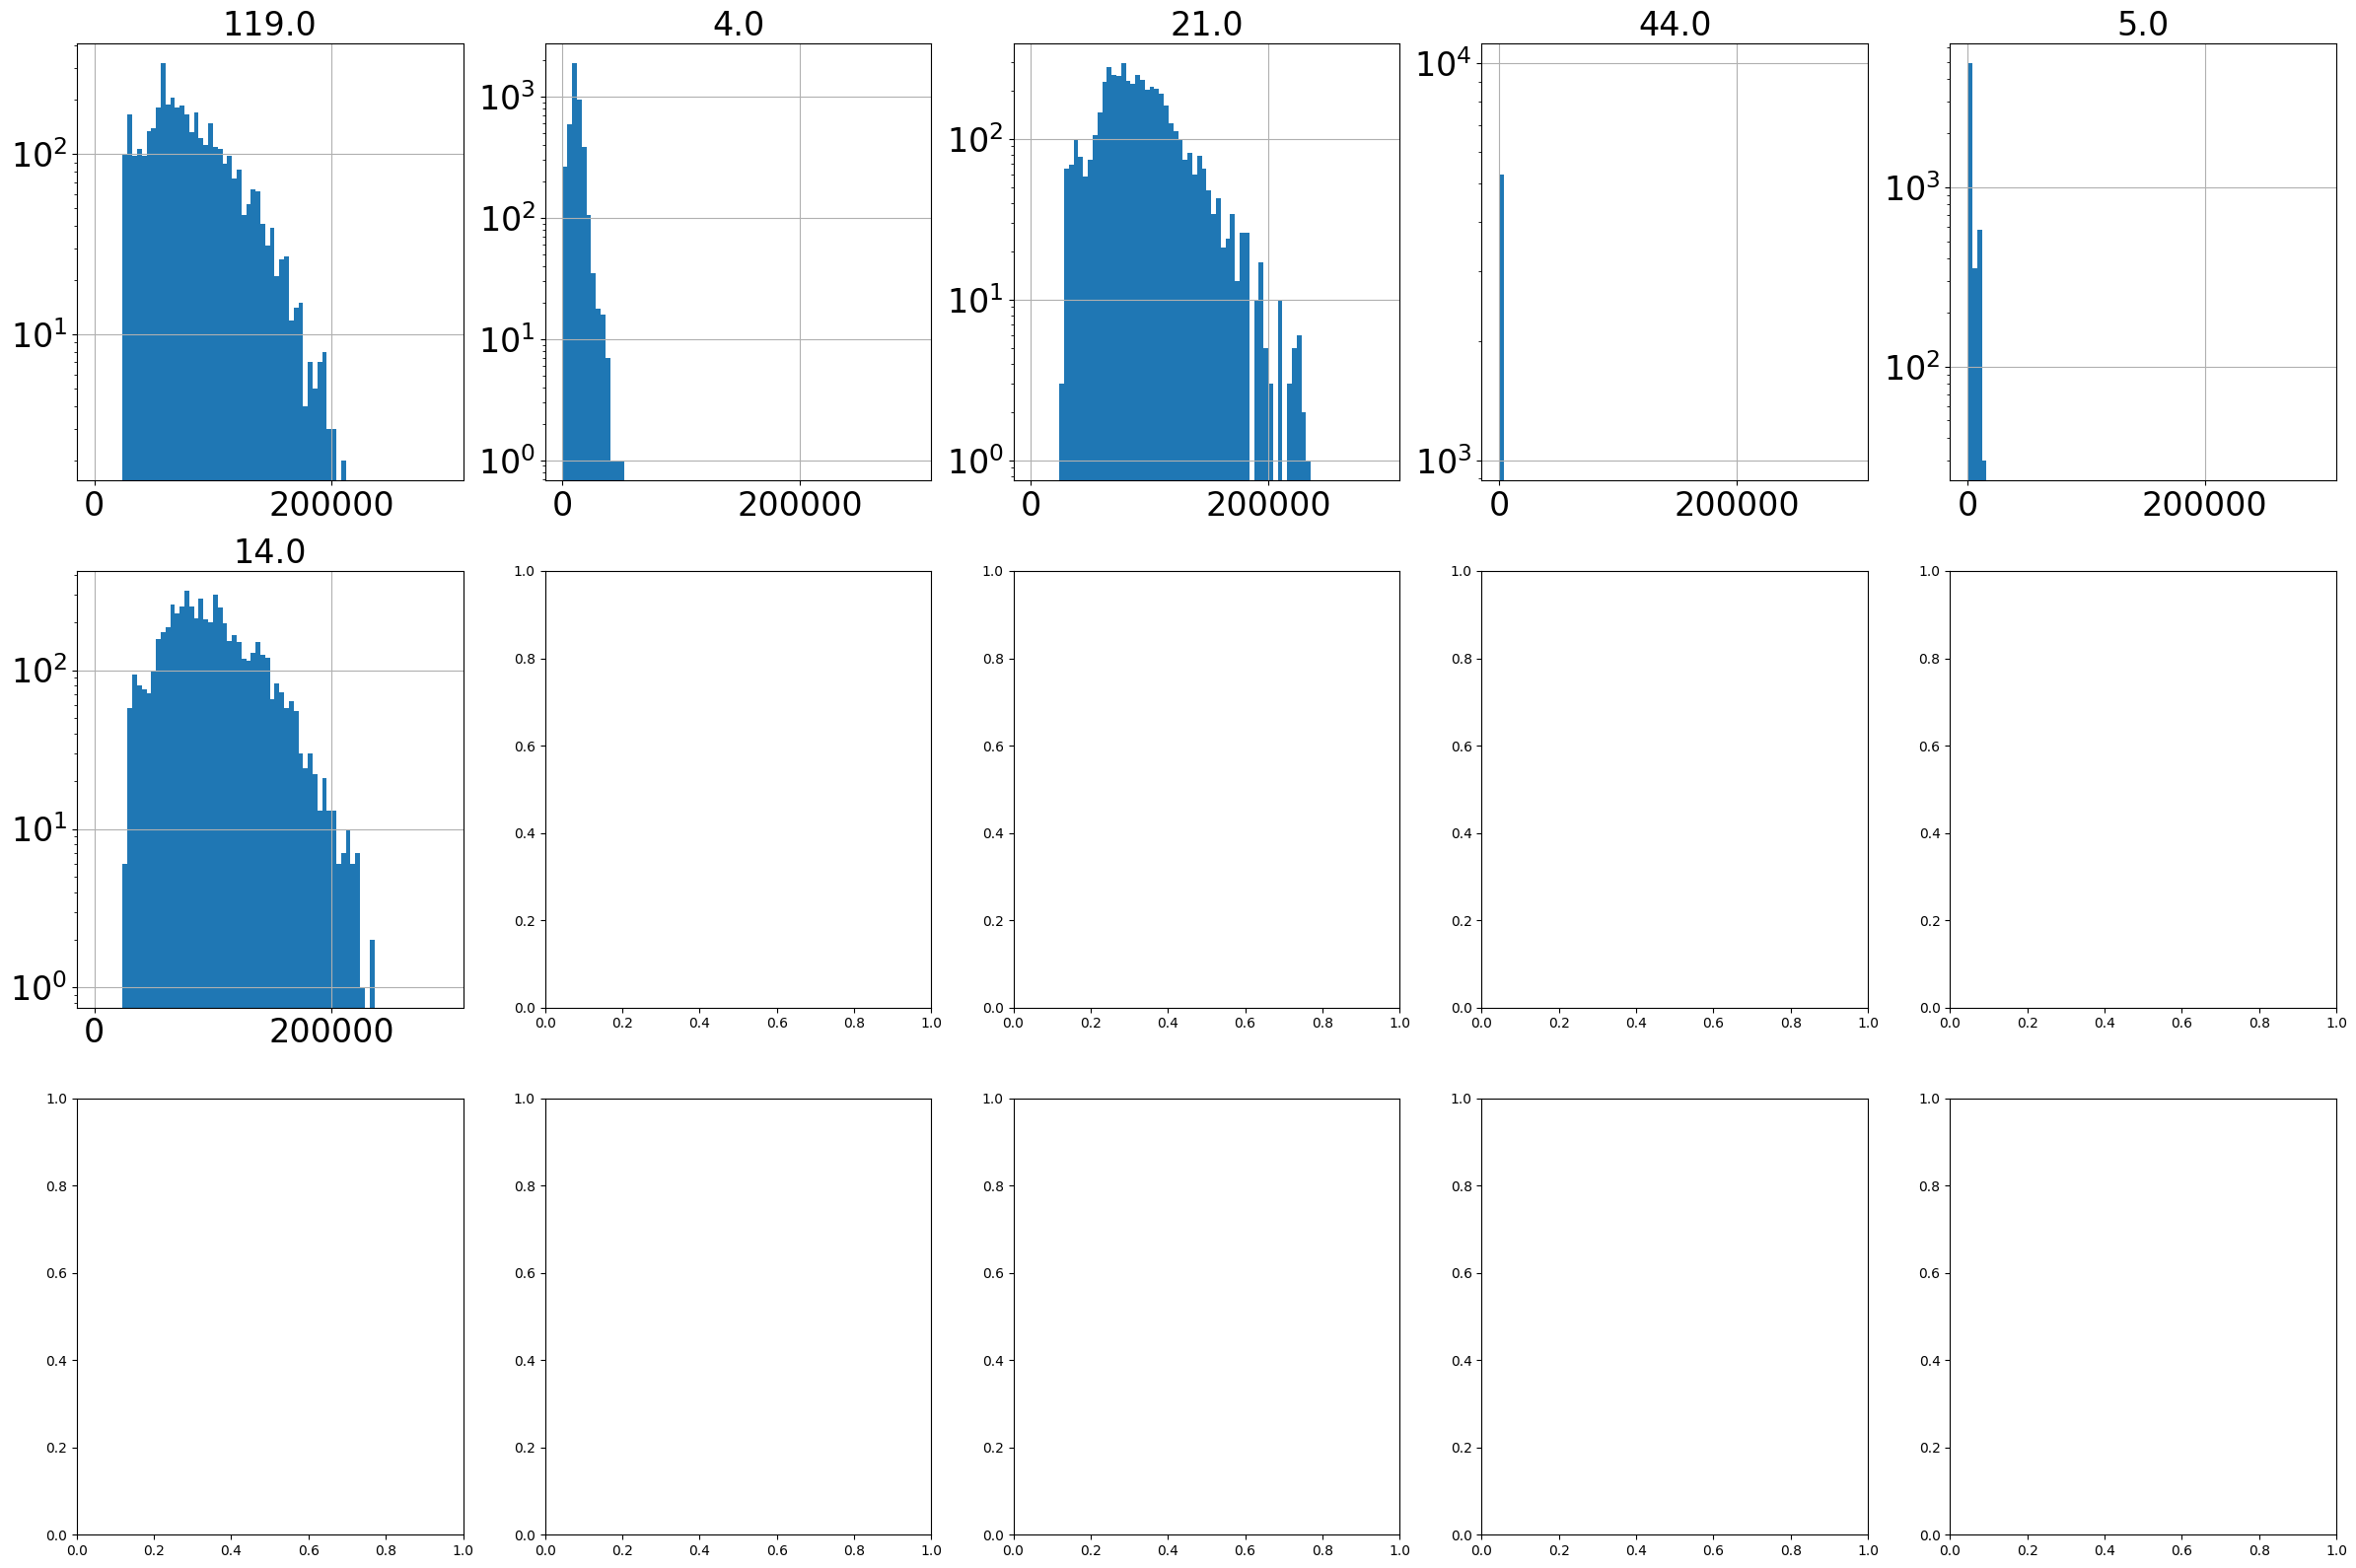

In [76]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.05)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()
plt.show()

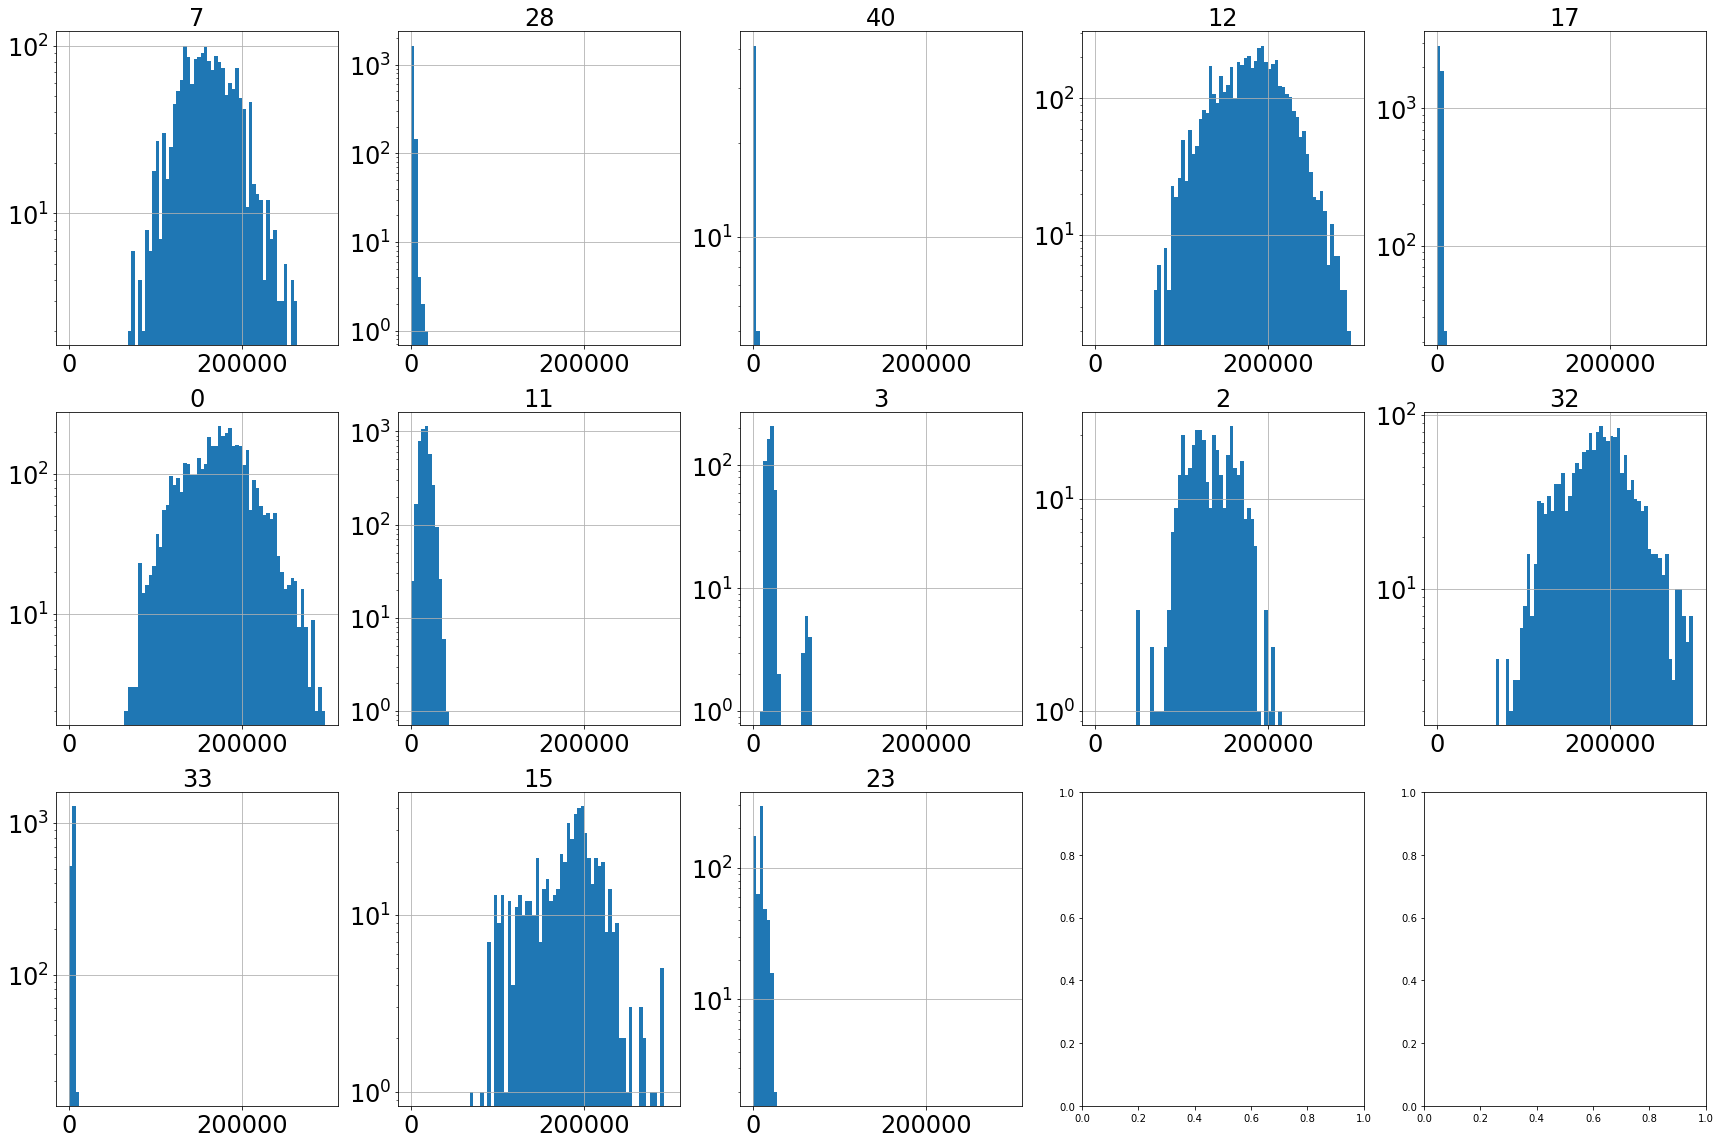

In [56]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.5)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

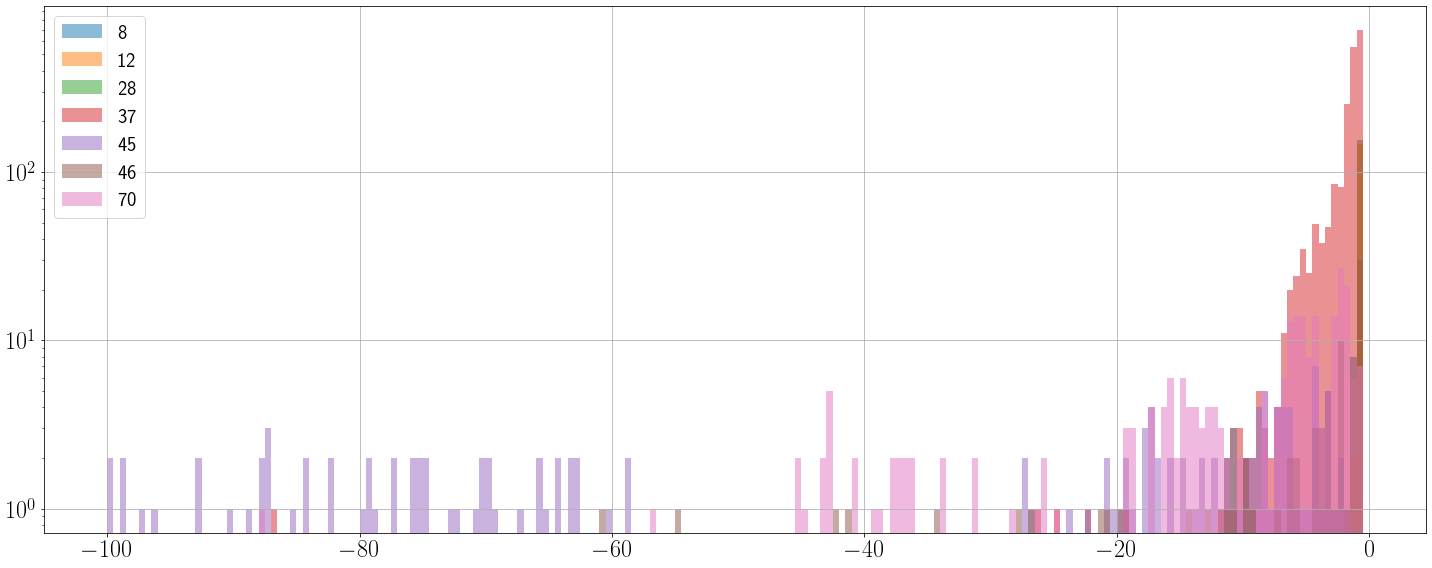

In [531]:
f,ax = plt.subplots(figsize=(20,8))
maxval = int(1e2)#4e5
bins = np.arange(-maxval,0,0.5) 
for label in np.unique(selected_cluster_labels):
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.1)].rocof.hist(log = True, 
                                                                                                bins = bins, 
                                                                                                ax = ax,
                                                                                                alpha = .5,
                                                                                                label = label) 
#ax.set_title(label,fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 20)
plt.tight_layout()
plt.show()

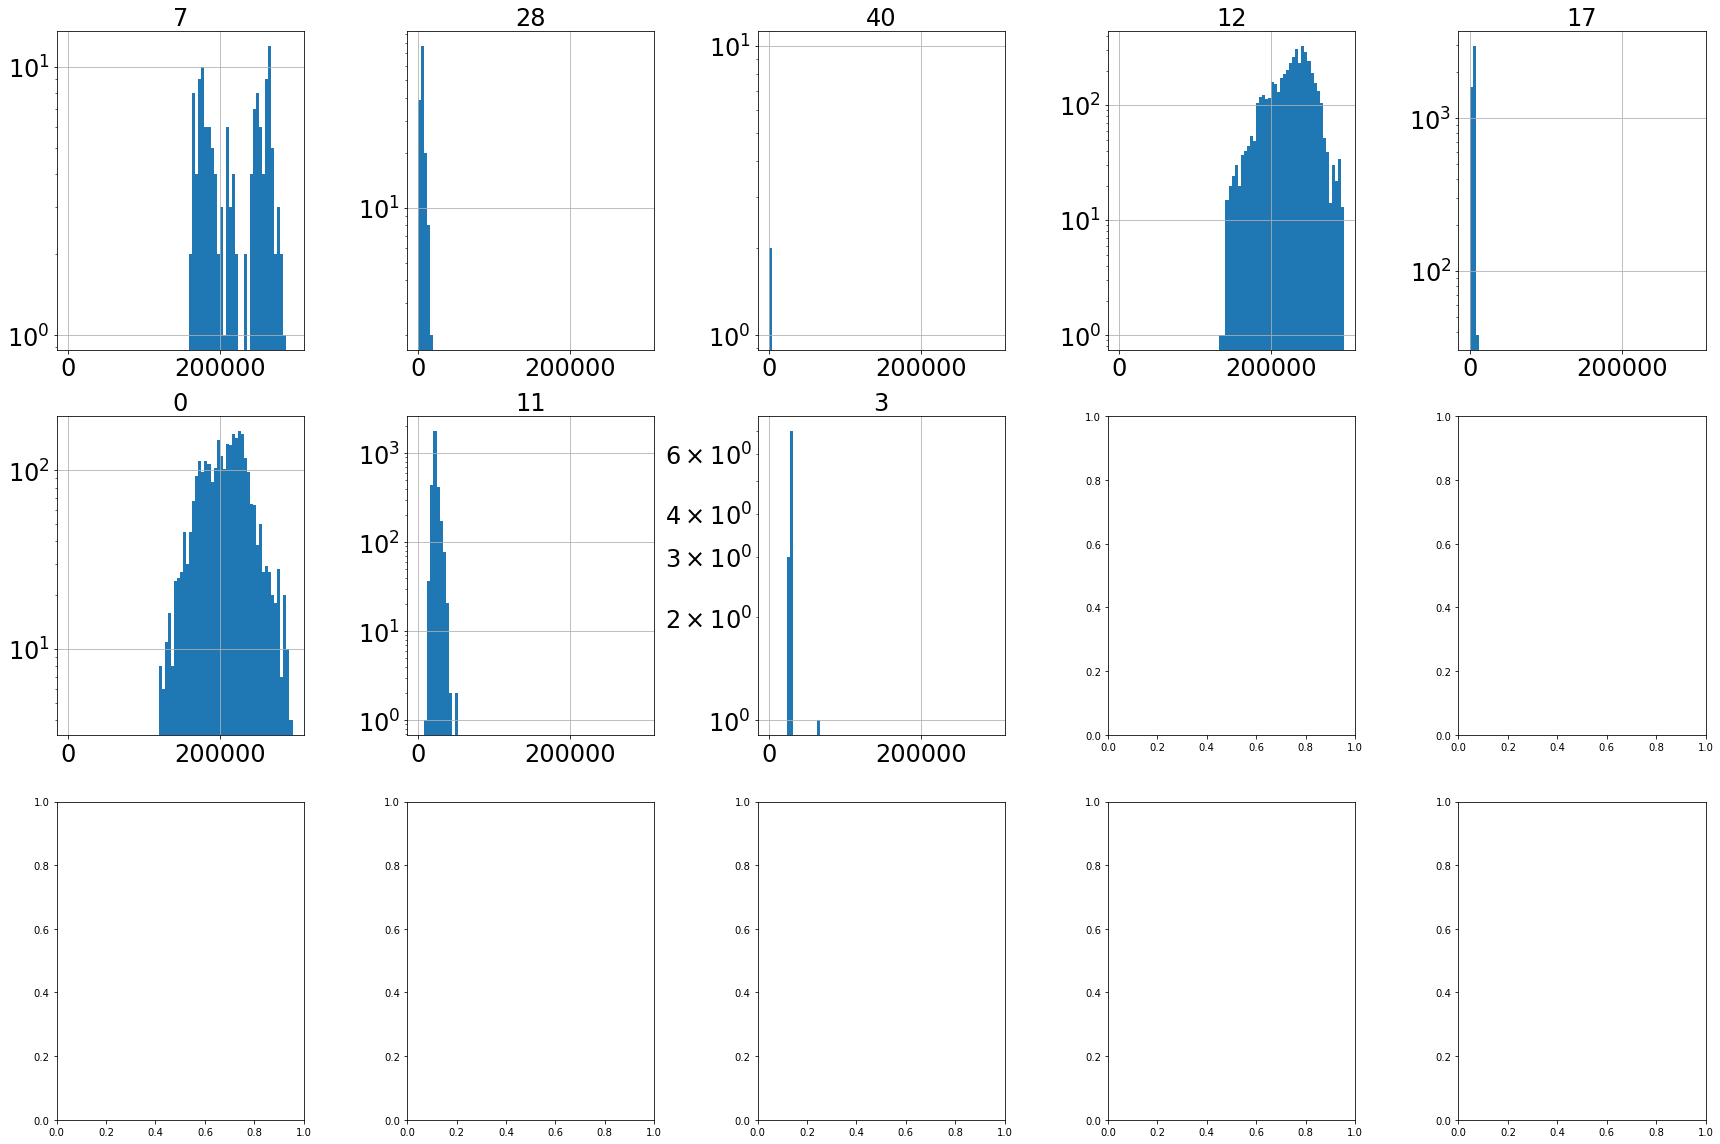

In [294]:
f,ax = plt.subplots(3,5,figsize=(24,16))
maxval = int(3e5)#4e5
bins = np.arange(0,maxval,4000)

for count,label in enumerate(selected_cluster_labels.unique()):
    
    xcoord = int(count//5)
    ycoord = int(count%5)
    
    component_props[(component_props.cluster_label==label) & (component_props.co2l==0.9)].inertia_proxy.hist(log = True, 
                                                                                                             bins = bins, 
                                                                                                             ax = ax[xcoord,ycoord])
    ax[xcoord,ycoord].set_title(label,fontsize = 24)
    ax[xcoord,ycoord].tick_params(axis = 'both', which = 'both', labelsize = 24)
plt.tight_layout()

## Visualise in likelihoode <-> rocof space

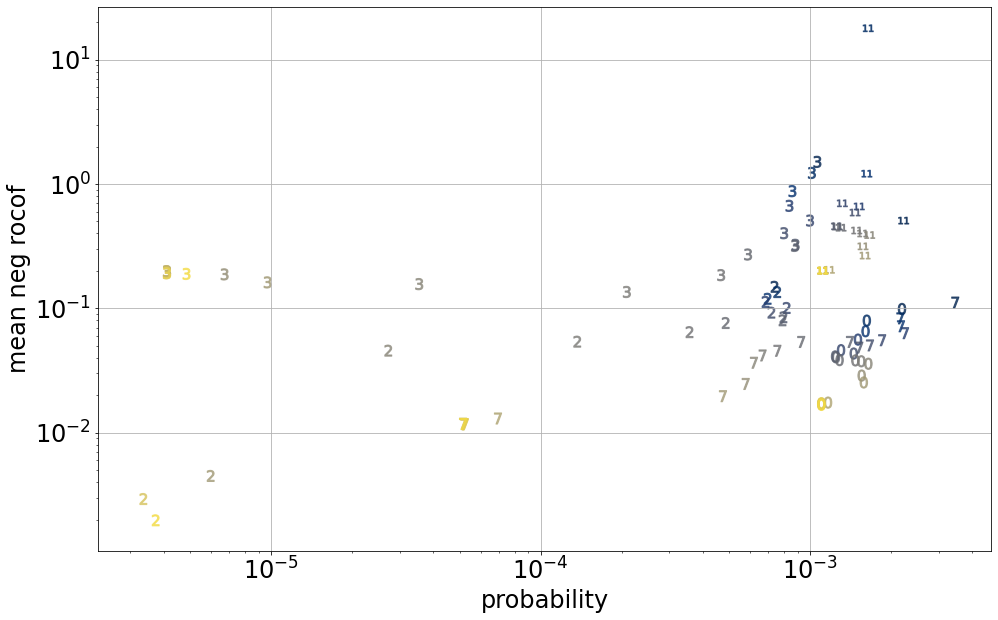

In [137]:
cmap = plt.get_cmap('cividis')
colors = [cmap(i/points.shape[0]) for i in range(points.shape[0])]
f,ax = plt.subplots(figsize = (16,10))
ax.grid(True)
indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()


for i in range(5):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],cluster_props.loc[selected_cluster].loc[indices[i]]['mean_neg_rocof']]).T

    
    ax.scatter(points[:, 0], 
                points[:, 1],
               c = colors,
               s = 500,
               alpha = 0.7,
               marker =  TextPath((0,0), str(indices[i])),#str(indices[i]),
               label = indices[i])#, points[1:, 0]-points[:-1, 0], points[1:, 1]-points[:-1, 1])
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('mean neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)

#ax.legend(fontsize = 24)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]
5.0
7.0
8.0
10.0
16.0
56.0


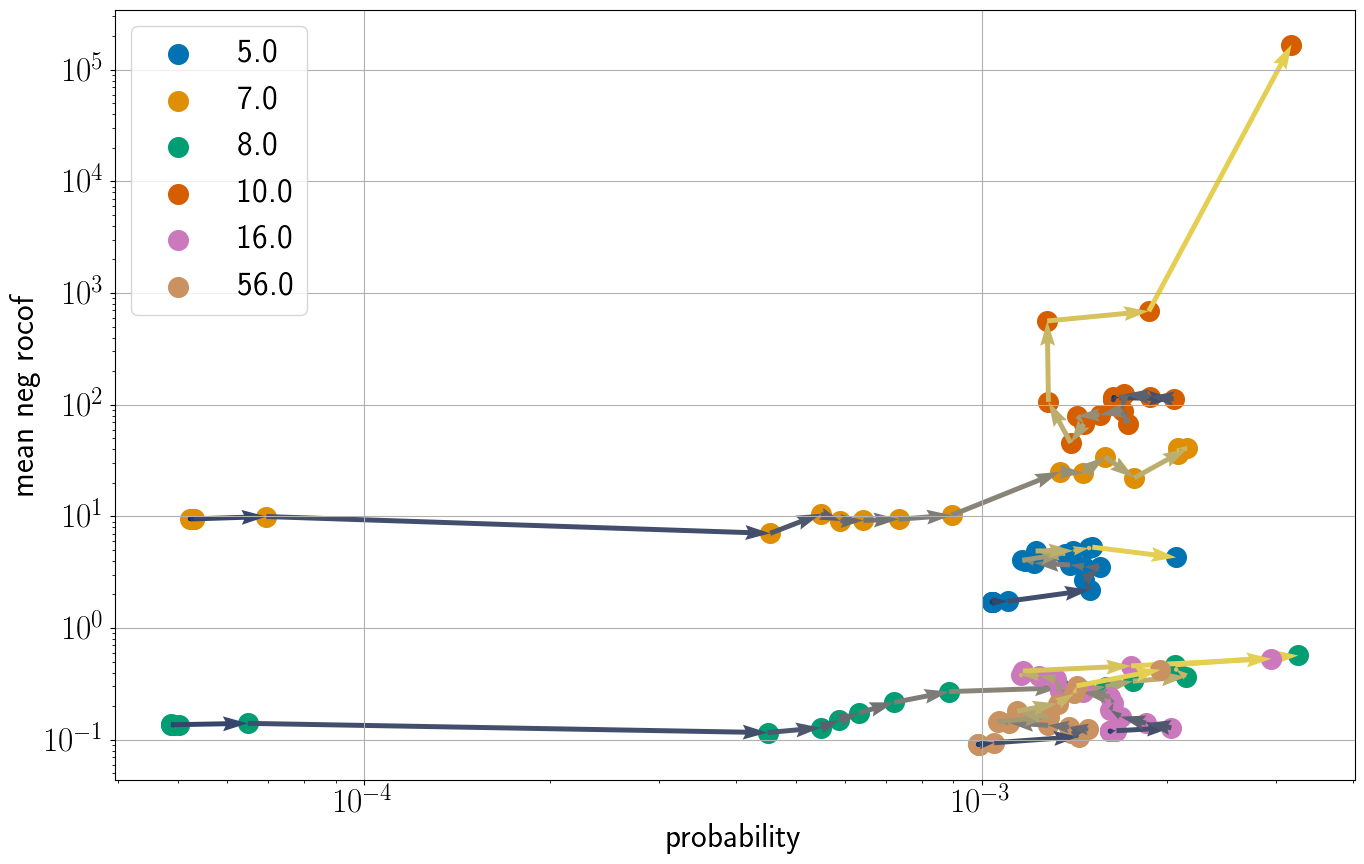

In [55]:
cmap = plt.get_cmap('cividis')

f,ax = plt.subplots(figsize = (16,10))

ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

colors_points = sns.color_palette('colorblind')

print(colors_points)

for i,cluster in enumerate(selected_cluster[:10]):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['max_neg_rocof']]).T##mean_neg_rocof

    
    colors = [cmap(i/len(co2ls)) for i in range(len(co2ls)-1)]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = cluster)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('mean neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 24)
plt.show()

4.0
5.0
14.0
21.0
44.0
119.0


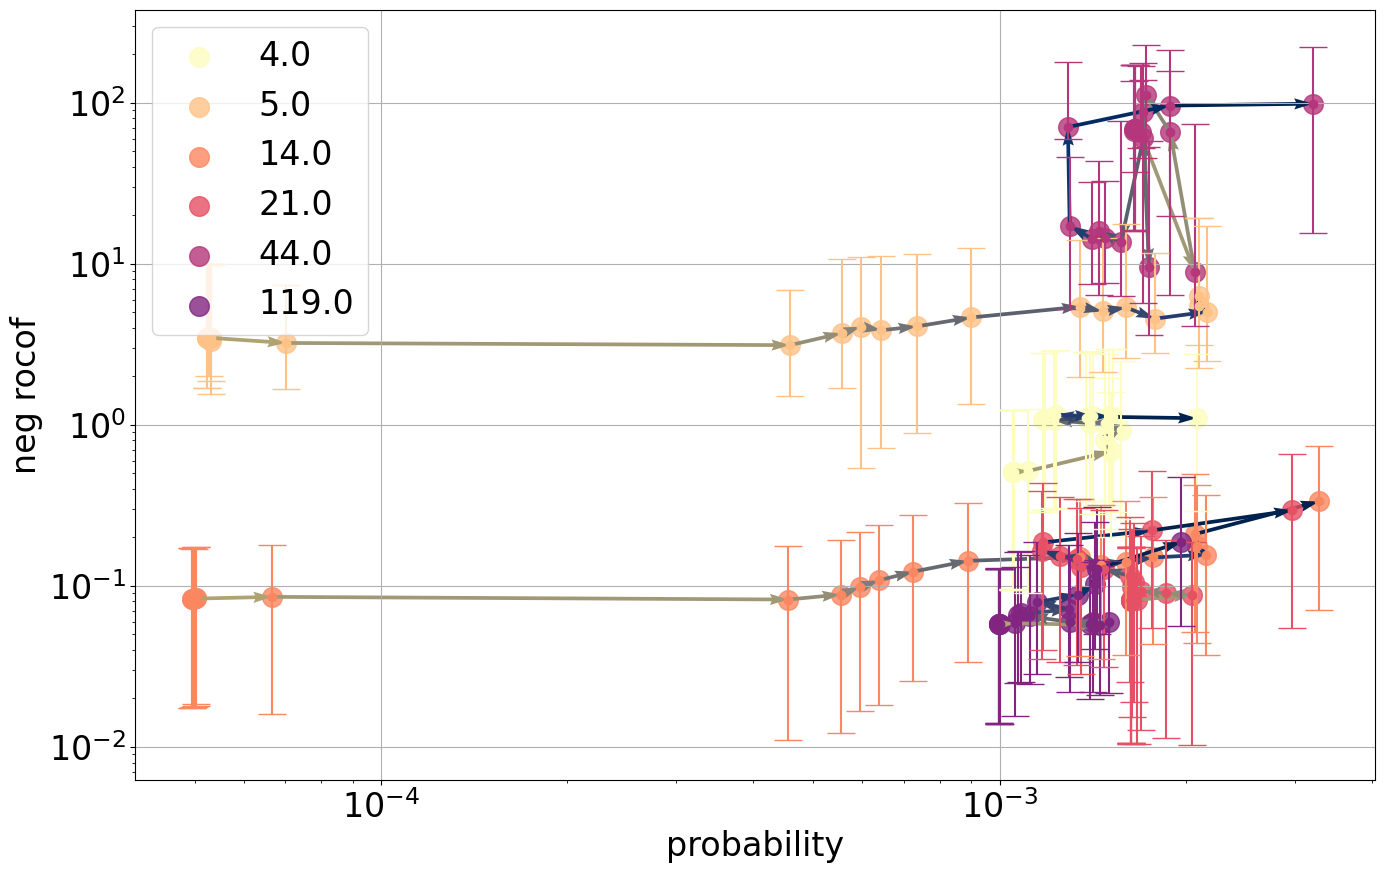

In [77]:
## cmap = plt.get_cmap('cividis')

f,ax = plt.subplots(figsize = (16,10))

ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

cmap = plt.get_cmap('magma_r')

colors_points = [cmap(i/(len(selected_cluster)+2)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')


start_index = 6

cmap = plt.get_cmap('cividis')

for i,cluster in enumerate(selected_cluster[:start_index+1]):#enumerate(selected_cluster[start_index:start_index+1],start_index):
    
    points = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['likelihood'],
                       cluster_props.loc[selected_cluster].loc[indices[i]]['median_neg_rocof']]).T##mean_neg_rocof

    
    colors = [cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = cluster,
              alpha = 0.8)
    yerr = np.array([cluster_props.loc[selected_cluster].loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[selected_cluster].loc[indices[i]]['lower_quantile_neg_rocof']])
    #print(yerr)
    ax.errorbar(points[:, 0],
                 points[:, 1], 
                 yerr = yerr, 
                 fmt = 'o',
                color = colors_points[i],
               capsize = 10)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.003,# 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('probability', fontsize = 24)
ax.set_ylabel('neg rocof', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)
ax.legend(fontsize = 24)
plt.show()

## Summary plot

0 5.0
5.0
1 7.0
7.0
2 8.0
8.0
3 10.0
10.0
4 16.0
16.0
5 56.0
56.0


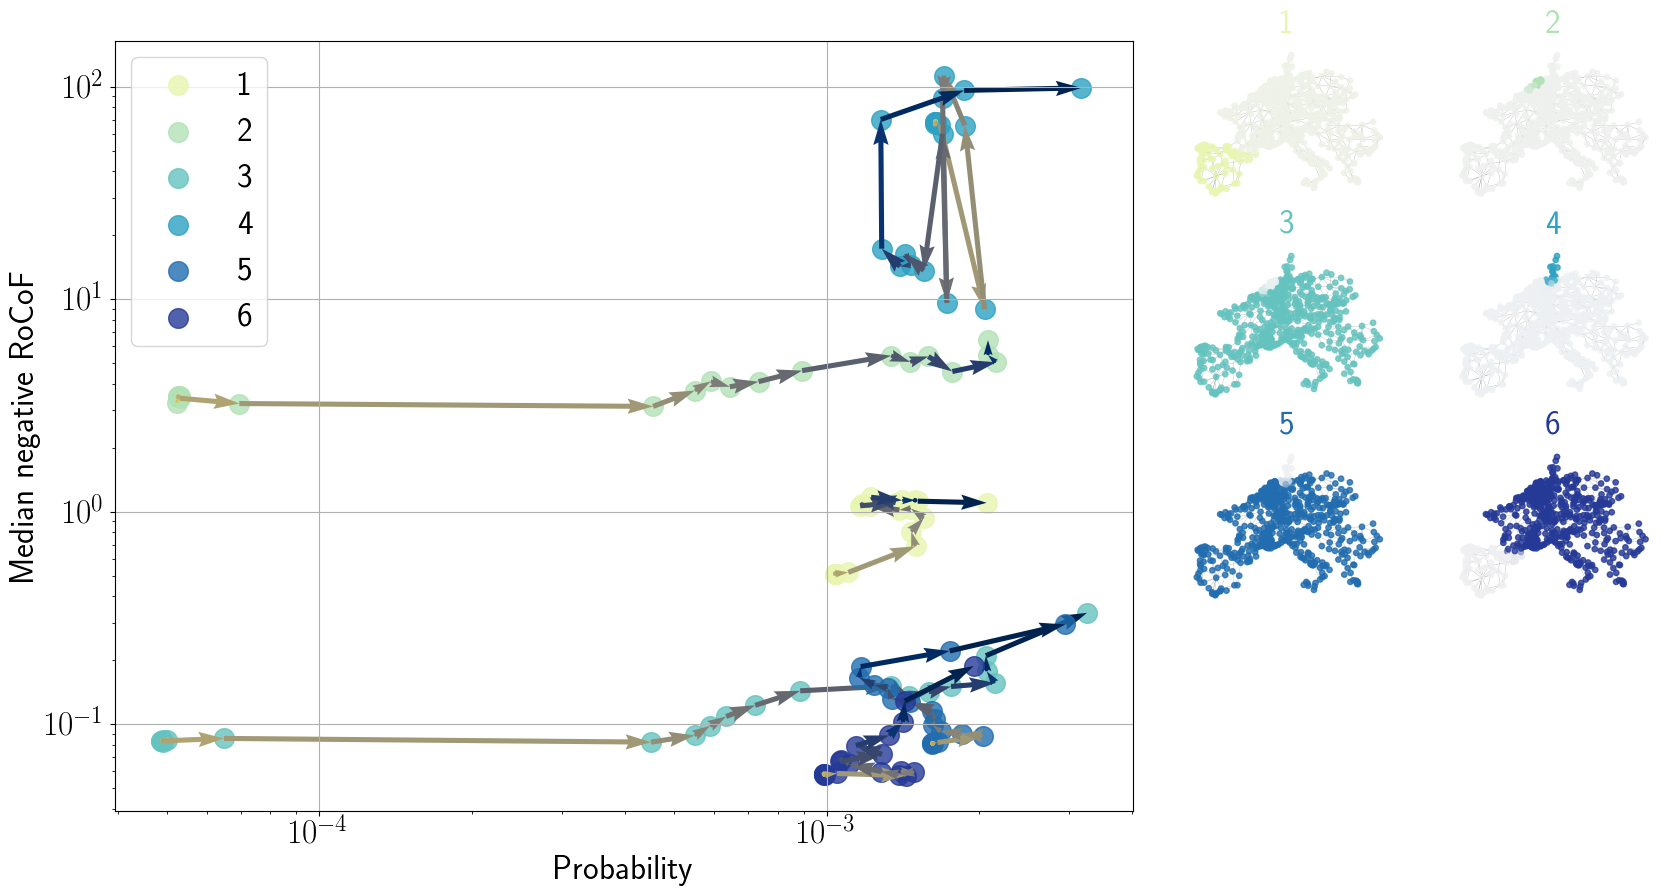

In [52]:
## cmap = plt.get_cmap('cividis')
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

f = plt.figure(figsize = (20,10))

gs = GridSpec(4, 6, figure = f)

axs = []

for i in range(4):
    axs.append([])
    for j in range(2):
        axs[i].append(f.add_subplot(gs[i, j+4]))
        axs[i][j].axis('off')
        
ax = f.add_subplot(gs[:,:4])


ax.grid(True)

indices = cluster_props.loc[selected_cluster].index.get_level_values(0).unique()

from palettable.cartocolors.sequential import agSunset_7
from palettable.colorbrewer.sequential import YlGnBu_9

cmap = YlGnBu_9.mpl_colormap#agSunset_7.mpl_colormap #Solar_3.mpl_colormap

colors_points = [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')


start_index = 6


for i,cluster in enumerate(selected_cluster[:start_index+1]):#enumerate(selected_cluster[start_index:start_index+1],start_index):
    print(i,cluster)
    co2_cmap = plt.get_cmap('cividis')
    points = np.array([cluster_props.loc[indices[i]]['likelihood'],
                       cluster_props.loc[indices[i]]['median_neg_rocof']]).T###['mean_neg_rocof']]).T#
    
    colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]

    ax.scatter(points[:, 0], 
               points[:, 1],
               s = 200, 
               color = colors_points[i],
              label = str(i+1),#cluster,
              alpha = 0.8)
    yerr = np.array([cluster_props.loc[indices[i]]['upper_quantile_neg_rocof'],
                     cluster_props.loc[indices[i]]['lower_quantile_neg_rocof']])
    #print(yerr)
    #ax.errorbar(points[:, 0],
    #             points[:, 1], 
    #             yerr = yerr, 
    #             fmt = 'o',
    #            color = colors_points[i],
    #           capsize = 10)
    
    ax.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
          (points[:-1, 0]-points[1:,0])[::-1],
          (points[:-1, 1]-points[1:,1])[::-1],
          angles = 'xy', 
          scale_units = 'xy',
          scale = 1,
          width = 0.005,# 0.004,
         color = colors)
    
    print(cluster)
ax.set_yscale('log')    
ax.set_xscale('log')    
ax.set_xlabel('Probability', fontsize = 24)
ax.set_ylabel('Median negative RoCoF', fontsize = 24)
ax.tick_params(axis = 'both', which = 'both', labelsize = 24)#
ax.legend(fontsize = 24)

#########################################

    
node_positions = nx.get_node_attributes(G,'pos')
    
sorted_labels = np.unique(selected_cluster_labels.values)

for i, label in enumerate(sorted_labels):
    xcoord = int(i//2)
    ycoord = int(i%2)
    cmap2 = sns.light_palette(cmap((i+1)/(len(selected_cluster)+1)), as_cmap=True)
    
    mean_ind_vector = np.array([selected_ind_vectors[selected_cluster_labels.values == label].mean(0) ])

    nx.draw(G,
            pos = node_positions,
            node_size = 15,
            width = 0.1,
            alpha = 0.8,
            ax = axs[xcoord][ycoord],
            node_color = mean_ind_vector,
            cmap = cmap2,
            vmin = 0,
            vmax = 1)


    axs[xcoord][ycoord].set_title('{}'.format(str(i+1)), #label
                                  fontsize = 24,
                                 color = cmap((i+1)/(len(selected_cluster)+1)))

path = '/media/fkaiser/'
save_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/'

#plt.savefig(save_path+'Figures/Figure6_risk_probability_plot.pdf',bbox_inches = 'tight')

plt.show()

## Analyse correlation with generation

In [676]:
component_props["co2l_str"] = component_props["co2l"].apply(lambda x: '{0:.2f}'.format(x)).astype(str)

In [727]:
correlations = pd.DataFrame(index = pd.MultiIndex.from_product([selected_cluster,['{0:.2f}'.format(co2ls[i]) for i in range(len(co2ls))]],
                                                                names = ["cluster", "co2l"]),
                           columns = network.generators.carrier.unique())

In [728]:
for i,co2l in enumerate(co2ls):
    network = pypsa.Network()
    network.import_from_netcdf(path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{np.round(co2l,2)}-3H.nc') 
    
    G = utils.build_networkx_graph(network, snet_index = snet_index)
    
    co2lstr = '{0:.2f}'.format(co2l)
    print(co2lstr)
    for count,label in enumerate(selected_cluster):
        cluster_probability = component_props[component_props.cluster_label == label].groupby(['co2l_str','time_stamp']).size().to_frame('counts')
        current_probs = cluster_probability.loc[co2lstr]
        current_probs.index = current_probs.index.map(lambda x: utils.solution_key_to_pandas_timestamp(x))

        gens = network.generators[network.generators["bus"].isin(list(G.nodes()))]
        current_generation = network.generators_t.p.T.loc[list(gens.index)].groupby(gens["carrier"]).sum().T
        current_generation = current_generation.add(current_probs,fill_value = 0)
        correlations.loc[(label,co2lstr)] = current_generation.corr().loc['counts']


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.00
offwind-ac    0.209309
onwind        0.261294
solar        -0.201076
CCGT               NaN
OCGT               NaN
coal               NaN
ror           0.147127
offwind-dc     0.21664
biomass      -0.080364
nuclear      -0.185633
lignite            NaN
oil                NaN
geothermal         NaN
Name: (8, 0.00), dtype: object
offwind-ac     0.14735
onwind        0.022938
solar        -0.192362
CCGT               NaN
OCGT               NaN
coal               NaN
ror          -0.000513
offwind-dc    0.215891
biomass       0.122025
nuclear       0.078854
lignite            NaN
oil                NaN
geothermal         NaN
Name: (12, 0.00), dtype: object
offwind-ac    0.325292
onwind        0.172842
solar        -0.181129
CCGT               NaN
OCGT               NaN
coal               NaN
ror           -0.13888
offwind-dc    0.282221
biomass       0.036827
nuclear       0.158649
lignite            NaN
oil                NaN
geothermal         NaN
Name: (28, 0.00), dtype: object
off

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.05-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.05
offwind-ac    0.098016
onwind        0.142645
solar        -0.019791
CCGT         -0.153345
OCGT         -0.089843
coal         -0.082641
ror           0.123231
offwind-dc    0.154708
biomass       -0.06973
nuclear      -0.154008
lignite      -0.026926
oil          -0.058876
geothermal   -0.114287
Name: (8, 0.05), dtype: object
offwind-ac    0.162129
onwind        0.115402
solar        -0.130873
CCGT         -0.017156
OCGT           -0.0229
coal         -0.065795
ror          -0.051092
offwind-dc    0.329596
biomass       0.046933
nuclear       0.032931
lignite       -0.03289
oil           -0.03363
geothermal    0.077561
Name: (12, 0.05), dtype: object
offwind-ac    0.373306
onwind        0.252289
solar        -0.250112
CCGT          0.003671
OCGT         -0.010691
coal         -0.032258
ror           -0.05613
offwind-dc    0.385037
biomass       0.115808
nuclear       0.170927
lignite       -0.01096
oil          -0.047193
geothermal    0.271576
Name: (28, 0.05), dtype: object
off

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.1-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


...

0.85
offwind-ac    0.031621
onwind        0.256873
solar         0.033652
CCGT         -0.302453
OCGT         -0.162215
coal         -0.282078
ror           0.253205
offwind-dc    0.165707
biomass      -0.070763
nuclear       -0.32389
lignite        0.00046
oil          -0.111561
geothermal      0.1621
Name: (8, 0.85), dtype: object
offwind-ac    -0.06406
onwind        0.226213
solar        -0.105571
CCGT         -0.021286
OCGT         -0.108096
coal          0.014361
ror           0.106254
offwind-dc    0.194569
biomass       0.066441
nuclear      -0.116782
lignite       0.059411
oil          -0.032267
geothermal   -0.003154
Name: (12, 0.85), dtype: object
offwind-ac     0.58334
onwind        0.420257
solar        -0.107775
CCGT         -0.139081
OCGT         -0.049383
coal         -0.480075
ror           0.013242
offwind-dc    0.360144
biomass      -0.447255
nuclear       -0.18535
lignite      -0.353106
oil          -0.028319
geothermal    0.014577
Name: (28, 0.85), dtype: object
off

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.9-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.90
offwind-ac    0.029872
onwind        0.254892
solar         0.030685
CCGT         -0.303888
OCGT         -0.161304
coal         -0.283854
ror           0.257693
offwind-dc    0.162773
biomass      -0.070163
nuclear       -0.32437
lignite      -0.000486
oil          -0.111126
geothermal    0.161332
Name: (8, 0.90), dtype: object
offwind-ac     -0.0642
onwind        0.226208
solar        -0.105582
CCGT          -0.02079
OCGT         -0.108107
coal          0.014264
ror           0.106263
offwind-dc    0.194621
biomass       0.066444
nuclear      -0.117042
lignite       0.059776
oil          -0.033925
geothermal   -0.016169
Name: (12, 0.90), dtype: object
offwind-ac    0.583623
onwind        0.420845
solar        -0.106132
CCGT          -0.13917
OCGT         -0.049639
coal         -0.480774
ror           0.012562
offwind-dc    0.359057
biomass      -0.447623
nuclear      -0.184715
lignite      -0.353421
oil          -0.028393
geothermal    0.014774
Name: (28, 0.90), dtype: object
off

/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.95-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


0.95
offwind-ac    0.032335
onwind        0.254594
solar         0.031914
CCGT         -0.301378
OCGT         -0.159365
coal         -0.282466
ror           0.253642
offwind-dc    0.163029
biomass       -0.07274
nuclear      -0.323723
lignite      -0.005406
oil          -0.107504
geothermal    0.162302
Name: (8, 0.95), dtype: object
offwind-ac   -0.117602
onwind         0.25783
solar        -0.074567
CCGT          0.024799
OCGT         -0.090499
coal          0.075687
ror           0.169176
offwind-dc    0.147864
biomass       0.054269
nuclear      -0.076845
lignite       0.040757
oil           0.016902
geothermal    0.007434
Name: (12, 0.95), dtype: object
offwind-ac    0.583969
onwind        0.421702
solar        -0.106193
CCGT         -0.138926
OCGT         -0.048167
coal         -0.482228
ror           0.010124
offwind-dc    0.361033
biomass      -0.447296
nuclear      -0.186244
lignite      -0.352132
oil          -0.028057
geothermal    0.014197
Name: (28, 0.95), dtype: object
off

In [748]:
# Example of making your own norm.  Also see matplotlib.colors.
# From Joe Kington: This one gives two different linear ramps:
class MidpointNormalize(mplcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        mplcolors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # I'm ignoring masked values and all kinds of edge cases to make a
        # simple example...
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

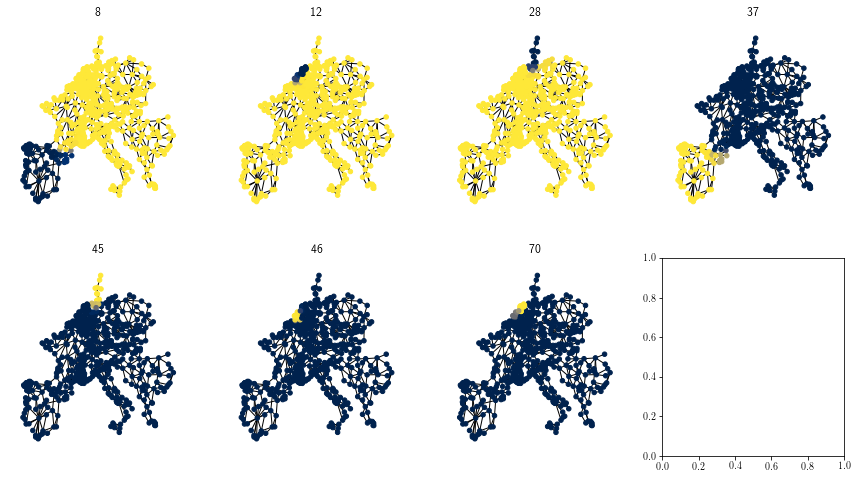

In [756]:
# Plot mean component vector of selected (cluster, co2l) samples
# (Does this make sense to only average over selected tuples?)

n_cols = 4 # adapt this value!

n_rows = np.ceil(n_selected_cluster/n_cols).astype(int)
fig,ax = plt.subplots(n_rows,n_cols,figsize = (15,4*n_rows))

#selected_components_mask = pd.MultiIndex.from_frame(component_props.loc[:,['cluster_label', 'co2l']]).isin(selected_cluster)
#selected_cluster_labels = component_props[selected_components_mask].cluster_label
#selected_ind_vectors = indicator_vectors[selected_components_mask]

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(selected_cluster)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(selected_cluster)].cluster_label

visualisation.plot_component_cluster(selected_ind_vectors,
                                     ax.flatten()[:n_selected_cluster],
                                     selected_cluster_labels.values,
                                     None,
                                     G)

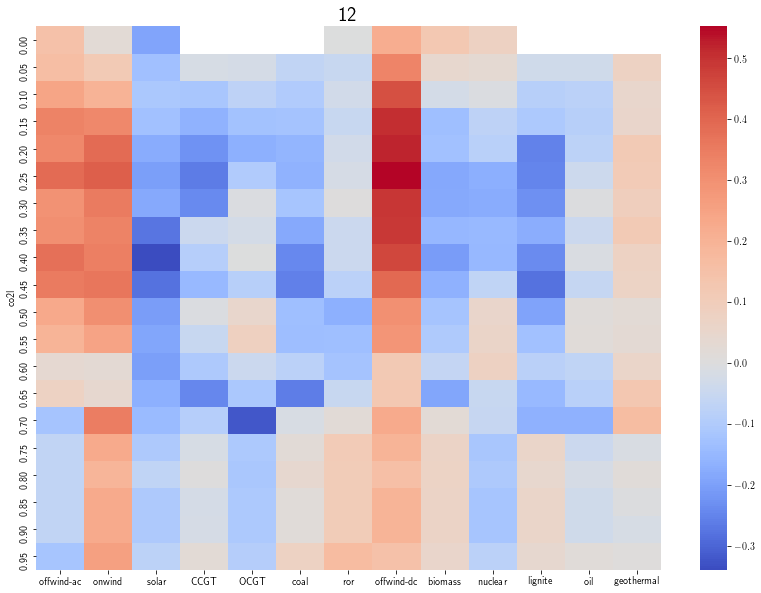

In [771]:
### correlation over time with total generation by type and frequency of occurence of a given split

current_cluster = selected_cluster[1]
test_df = (correlations.loc[current_cluster].copy()).astype("float")

vmin = test_df.min().min()
vmax = test_df.max().max()

norm = MidpointNormalize(midpoint = 0, vmin = vmin, vmax = vmax)  

f,ax = plt.subplots(figsize=(14,10))
sns.heatmap(data = test_df,
            norm = norm,
            cmap = plt.get_cmap('coolwarm'),
            ax = ax)
ax.set_title(current_cluster,fontsize = 20)
plt.show()